In [47]:
import sys
import os
import subprocess

# 1. 시스템 레벨 확인 (NVIDIA 드라이버 및 WSL 인식 여부)
print("=== 1. System Level Check (nvidia-smi) ===")
try:
    nvidia_smi = subprocess.check_output(["nvidia-smi"]).decode("utf-8")
    print(nvidia_smi)
except Exception as e:
    print("Error: nvidia-smi command not found. Check if NVIDIA Driver is installed on Windows Host.")

# 2. PyTorch GPU 확인
print("\n=== 2. PyTorch GPU Check ===")
try:
    import torch
    cuda_available = torch.cuda.is_available()
    print(f"PyTorch Version: {torch.__version__}")
    print(f"CUDA Available: {cuda_available}")
    if cuda_available:
        print(f"Current GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU Count: {torch.cuda.device_count()}")
        # 실제 연산 테스트 (GPU로 텐서 이동)
        x = torch.tensor([1.0, 2.0]).cuda()
        print(f"Tensor Device: {x.device} (Success!)")
    else:
        print("Warning: PyTorch is installed but CUDA is not detected.")
except ImportError:
    print("PyTorch not installed.")

# 3. TensorFlow GPU 확인
print("\n=== 3. TensorFlow GPU Check ===")
try:
    import tensorflow as tf
    gpus = tf.config.list_physical_devices('GPU')
    print(f"TensorFlow Version: {tf.__version__}")
    print(f"GPUs Detected: {len(gpus)}")
    for i, gpu in enumerate(gpus):
        print(f" - GPU {i}: {gpu}")
    if len(gpus) > 0:
        # 실제 연산 테스트
        with tf.device('/GPU:0'):
            a = tf.constant([[1.0, 2.0]])
            print(f"TensorFlow Operation on GPU: Success!")
except ImportError:
    print("TensorFlow not installed.")

=== 1. System Level Check (nvidia-smi) ===
Wed Mar 11 17:11:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.45.03              Driver Version: 595.71         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...    On  |   00000000:01:00.0  On |                  N/A |
| 30%   39C    P0             32W /  220W |    3638MiB /  12282MiB |      5%      Default |
|                                         |                        |                  N/A |
+----

2026-03-11 17:11:30.914903: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-11 17:11:31.254309: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-11 17:11:32.683304: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow Version: 2.20.0
GPUs Detected: 1
 - GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


I0000 00:00:1773216693.024302   61974 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9513 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


TensorFlow Operation on GPU: Success!


# [Step 1] 대리 모델(Surrogate)을 통한 데이터 증강 — v2 (Improved)

> **목표:** ~900개의 생존 시뮬레이션 데이터에서 300초 시계열의 **'절댓값 Max Peak(부호 유지)'**를 추출하고,  
> GBR(Gaussian Process Regression) 대리 모델을 학습하여 **10만 개의 가상 P1~P6 조합**에 대한 응력/변형 결과를 예측합니다.

### 핵심 물리 로직: '절댓값 Max Peak' 추출
열 사이클링에서 응력은 가열 시 (+), 냉각 시 (-) 방향으로 진동합니다.  
**단순 max()를 쓰면 냉각 시 압축 응력(음수)의 위험성을 놓칩니다.**  
따라서 `abs().idxmax()`로 절댓값이 가장 큰 시점을 찾되, 그 시점의 **원래 부호를 보존**합니다.

```python
# 절댓값이 가장 큰 시점의 인덱스 -> 해당 시점의 원본 값(부호 유지)
max_abs_idx = df_time[col].abs().idxmax()
peak_value  = df_time.loc[max_abs_idx, col]   # 예: -30 (압축 피크)
```

---
## 0. 환경 설정 및 라이브러리 로드

In [24]:
import os
import re
import glob
import time
import warnings
import platform
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

# ====================================================================
# [경로 자동 설정] Windows와 WSL(Linux) 환경을 자동 감지하여 경로 할당
# ====================================================================
if platform.system() == 'Linux':
    CSV_FOLDER = '/mnt/i/ai_model_dev/cfd/SIM_CSV_DATA'
    MASTER_CSV = '/mnt/i/ai_model_dev/cfd/Master_DOE_1200.csv'
    BASE_DIR   = '/mnt/i/ai_model_dev/cfd'
else:
    CSV_FOLDER = r'I:\\ai_model_dev\\cfd\\SIM_CSV_DATA'
    MASTER_CSV = r'I:\\ai_model_dev\\cfd\\Master_DOE_1200.csv'
    BASE_DIR   = r'I:\\ai_model_dev\\cfd'

Y_COLUMNS = [
    'WarpMax',          # 패키지 전체 최대 열변형량 (최소화 메인 타겟 #1)
    'T_Tip_Peel',       # Top 계면 끝단 수직응력 - 박리 원인 (최소화 메인 타겟 #2)
    'T_Tip_Shear',      # Top 계면 끝단 전단응력 - 계면 피로 유발
    'T_Tip_SEQV',       # Top 끝단 Von Mises 등가응력 - 소성 변형 유발
    'T_Tip_Strain',     # Top 끝단 변형률
    'T_Avg_Peel',       # Top 접합면 평균 수직응력 - 중앙부 Void 유발
    'T_Avg_Shear',      # Top 접합면 평균 전단응력
    'B_Tip_Peel',       # Bottom 끝단 수직응력
    'B_Tip_Shear',      # Bottom 끝단 전단응력
    'B_Tip_SEQV',       # Bottom 끝단 Von Mises 등가응력
    'B_Tip_Strain',     # Bottom 끝단 변형률
    'B_Avg_Peel',       # Bottom 평균 수직응력
    'B_Avg_Shear',      # Bottom 평균 전단응력
    'Die_SX',           # 다이(실리콘 칩) 휨 응력 - Die Crack 유발
    'Die_SY_Max'        # 다이 최대 Y방향 응력 - 모서리 응력 집중
]

# 물리적으로 항상 양수(>=0)인 변수 목록 (외삽 시 음수 clipping 대상)
# Von Mises 등가응력과 변형률은 정의상 음수가 될 수 없음
POSITIVE_ONLY_COLS = ['T_Tip_SEQV', 'T_Tip_Strain', 'B_Tip_SEQV', 'B_Tip_Strain']

SEED = 42
np.random.seed(SEED)

print('=== 환경 설정 완료 (GPR 모드) ===')
print(f'현재 감지된 OS: {platform.system()}')
print(f'시계열 CSV 폴더 : {CSV_FOLDER}')
print(f'마스터 DOE 파일 : {MASTER_CSV}')
print(f'추출 대상 Y 변수: {len(Y_COLUMNS)}개')
print(f'양수 전용 변수  : {POSITIVE_ONLY_COLS}')

=== 환경 설정 완료 (GPR 모드) ===
현재 감지된 OS: Linux
시계열 CSV 폴더 : /mnt/i/ai_model_dev/cfd/SIM_CSV_DATA
마스터 DOE 파일 : /mnt/i/ai_model_dev/cfd/Master_DOE_1200.csv
추출 대상 Y 변수: 15개
양수 전용 변수  : ['T_Tip_SEQV', 'T_Tip_Strain', 'B_Tip_SEQV', 'B_Tip_Strain']


---
## 1. 마스터 DOE 로드 및 생존 CSV 탐지

**데이터 구조 (확인 완료):**
- `Master_DOE_1200.csv`: P1~P6 컬럼만 존재 (Row_ID 없음, 1200행)
  - 행 인덱스(0-based) + 1 = Row_ID로 매핑
  - P1: [0.80, 1.10] / P2: [0.05, 0.09] / P3: [0.60, 0.72]
  - P4: [0.10, 0.30] / P5: [1.20, 1.80] / P6: [0.04, 0.08]
- 시계열 파일: `ML_DATA_Extract_Row_{Row_ID}.csv` (617행 x 17열, 0.1~300초)

In [25]:
# == 1-1. 마스터 DOE 로드 ==
# P1~P6만 존재하는 1200행 파일. Row_ID 컬럼이 없으므로 직접 부여함.
df_master = pd.read_csv(MASTER_CSV)

# Row_ID 생성: 행 인덱스 + 1 = CSV 파일명의 Row 번호와 1:1 대응
# 즉, Master CSV의 1번째 행(index=0) -> Row_ID=1 -> ML_DATA_Extract_Row_1.csv
df_master.insert(0, 'Row_ID', range(1, len(df_master) + 1))

print(f'마스터 DOE 로드 완료: {len(df_master)}개 DP (Design Points)')
print(f'컬럼: {list(df_master.columns)}')
print()

# 각 P 변수의 범위 확인 (몬테카를로 생성 시 바운더리로 사용됨)
print('-- P1~P6 실제 범위 --')
for col in ['P1','P2','P3','P4','P5','P6']:
    print(f'  {col}: [{df_master[col].min():.4f}, {df_master[col].max():.4f}]')

display(df_master.head())

마스터 DOE 로드 완료: 1200개 DP (Design Points)
컬럼: ['Row_ID', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6']

-- P1~P6 실제 범위 --
  P1: [0.8005, 1.0998]
  P2: [0.0500, 0.0899]
  P3: [0.6001, 0.7198]
  P4: [0.1000, 0.2994]
  P5: [1.2003, 1.7997]
  P6: [0.0401, 0.0800]


,Row_ID,P1,P2,P3,P4,P5,P6
0,1,0.8317,0.0842,0.6021,0.1075,1.7454,0.0585
1,2,0.8143,0.0777,0.7136,0.1333,1.4174,0.0696
2,3,0.8013,0.0512,0.6363,0.2312,1.3751,0.0560
3,4,1.0509,0.0569,0.6031,0.2220,1.2660,0.0777
4,5,0.8744,0.0670,0.6206,0.2669,1.4158,0.0779


In [26]:
# == 1-2. 생존 CSV 파일 자동 탐지 ==
# 폴더를 스캔하여 실제 존재하는 시계열 파일의 Row_ID를 파싱
# (시뮬레이션이 터진 DP는 CSV 파일 자체가 생성되지 않음)

# glob으로 해당 폴더의 모든 ML_DATA_Extract_Row_*.csv 파일 탐색
pattern = os.path.join(CSV_FOLDER, 'ML_DATA_Extract_Row_*.csv')
found_files = sorted(glob.glob(pattern))

# 파일명에서 Row_ID 숫자를 정규식으로 추출
survived_ids = []
for fpath in found_files:
    fname = os.path.basename(fpath)
    match = re.search(r'Row_(\d+)\.csv', fname)
    if match:
        survived_ids.append(int(match.group(1)))

survived_ids = sorted(survived_ids)

# 전체 DP 수 = 폴더 내 가장 큰 Row_ID (실제 시뮬레이션이 시도된 총 수)
n_total = max(survived_ids)
n_alive = len(survived_ids)
n_dead  = n_total - n_alive

print(f'전체 DP      : {n_total}개 (최대 Row_ID 기준)')
print(f'생존 CSV     : {n_alive}개 ({n_alive/n_total*100:.1f}%)')
print(f'결측(터진) DP: {n_dead}개 ({n_dead/n_total*100:.1f}%)')
print(f'생존 Row_ID 범위: {min(survived_ids)} ~ {max(survived_ids)}')

전체 DP      : 903개 (최대 Row_ID 기준)
생존 CSV     : 666개 (73.8%)
결측(터진) DP: 237개 (26.2%)
생존 Row_ID 범위: 1 ~ 903


---
## 2. 시계열 데이터에서 '절댓값 Max Peak' 추출 (Feature Extraction)

각 생존 CSV(300초, 617 timestep)에서 15개 Y 채널별로:
1. `abs().idxmax()` -> 절댓값이 최대인 시간 인덱스 탐색
2. 해당 시점의 원본 값(부호 유지)을 피크로 기록

결과: **[Row_ID, P1~P6, Y1_peak ~ Y15_peak]** 형태의 정적 데이터셋 구축

In [27]:
# == 2-1. 생존 데이터 순회 및 Max Peak 추출 ==

valid_data = []     # 정상 추출된 데이터를 누적할 리스트
error_rows = []     # 읽기 오류가 발생한 Row_ID를 기록할 리스트

t_start = time.time()
print(f'{len(survived_ids)}개 생존 CSV에서 Max Peak 추출 시작...')

for i, row_id in enumerate(survived_ids):
    # 시계열 CSV 파일 경로 구성
    fpath = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    
    try:
        # 시계열 데이터 로드 (617행 x 17열: Time, TempBase, 15 Y변수)
        df_ts = pd.read_csv(fpath)
        
        # 컬럼명 앞뒤 공백 제거 (CSV 헤더에 공백 포함될 수 있음)
        df_ts.columns = [c.strip() for c in df_ts.columns]
        
        # 마스터 DOE에서 해당 Row의 P1~P6 가져오기
        # Row_ID는 1-based이므로, df_master에서 Row_ID == row_id인 행을 찾음
        master_row = df_master[df_master['Row_ID'] == row_id]
        if master_row.empty:
            error_rows.append((row_id, 'Master DOE에 해당 Row_ID 없음'))
            continue
        
        # 결과 딕셔너리 초기화
        peak_dict = {'Row_ID': row_id}
        
        # P1~P6 설계변수 값 저장
        for p_col in ['P1','P2','P3','P4','P5','P6']:
            peak_dict[p_col] = master_row[p_col].values[0]
        
        # === 핵심 로직: 각 Y 채널별 '절댓값 최대 피크(부호 유지)' 추출 ===
        for y_col in Y_COLUMNS:
            if y_col in df_ts.columns:
                # Step A: 300초 시계열에서 절댓값이 가장 큰 시간 인덱스 탐색
                #   abs()로 절댓값을 취한 뒤 idxmax()로 최대 위치를 찾음
                max_abs_idx = df_ts[y_col].abs().idxmax()
                
                # Step B: 해당 시점의 원래 값(부호 보존)을 피크로 기록
                #   예) 시계열이 [+10, -30, +20]이면:
                #       abs = [10, 30, 20] -> idxmax = 1 -> 원본값 = -30
                #   이렇게 해야 냉각 시 압축 응력의 위험성을 놓치지 않음
                peak_dict[y_col] = df_ts.loc[max_abs_idx, y_col]
            else:
                # 해당 Y 컬럼이 CSV에 없는 경우 NaN 처리
                peak_dict[y_col] = np.nan
        
        valid_data.append(peak_dict)
        
    except Exception as e:
        error_rows.append((row_id, str(e)))
    
    # 진행률 표시 (200개마다)
    if (i + 1) % 200 == 0:
        print(f'  ... {i+1}/{len(survived_ids)} 처리 완료')

elapsed = time.time() - t_start

# 결과 취합
df_peaks = pd.DataFrame(valid_data)

print(f'\n=== Max Peak 추출 완료 ===')
print(f'성공: {len(df_peaks)}개 / 실패: {len(error_rows)}개 / 소요시간: {elapsed:.1f}초')

if error_rows:
    print(f'\n[경고] 오류 발생 Row (처음 5개): {error_rows[:5]}')

# NaN이 있는 행 확인 및 제거
nan_count = df_peaks[Y_COLUMNS].isnull().any(axis=1).sum()
if nan_count > 0:
    print(f'[경고] {nan_count}개 행에 NaN 존재 -> 해당 행 제거')
    df_peaks = df_peaks.dropna(subset=Y_COLUMNS).reset_index(drop=True)

print(f'\n최종 학습용 데이터: {len(df_peaks)}개')
display(df_peaks.head())

666개 생존 CSV에서 Max Peak 추출 시작...
  ... 200/666 처리 완료
  ... 400/666 처리 완료
  ... 600/666 처리 완료

=== Max Peak 추출 완료 ===
성공: 666개 / 실패: 0개 / 소요시간: 3.8초

최종 학습용 데이터: 666개


,Row_ID,P1,P2,P3,P4,P5,P6,WarpMax,T_Tip_Peel,T_Tip_Shear,...,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
0,1,0.8317,0.0842,0.6021,0.1075,1.7454,0.0585,-0.107084,-34.039048,-8.025589,...,0.023255,-3.071933,-5.445917,-2.957903,28.329506,0.002043,0.032548,-2.861042,66.203874,-85.012494
1,2,0.8143,0.0777,0.7136,0.1333,1.4174,0.0696,-0.144790,-31.629051,8.315480,...,0.031333,-2.707141,-4.092614,-2.676881,25.607135,0.001761,0.025406,-2.568996,63.021576,-87.551451
2,4,1.0509,0.0569,0.6031,0.2220,1.2660,0.0777,-0.158005,-38.879585,8.994357,...,0.084601,-2.668019,-4.944124,-2.822713,29.147154,0.001970,-0.027274,-2.938019,61.316208,-86.130069
3,5,0.8744,0.0670,0.6206,0.2669,1.4158,0.0779,-0.138039,-33.084874,8.631955,...,0.031446,-2.621313,-4.015564,-2.296843,26.291782,0.001684,-0.015385,-2.606656,58.891827,-81.062810
4,7,0.9347,0.0506,0.6789,0.1163,1.6356,0.0661,-0.120482,-41.494301,8.232958,...,0.081118,-2.695119,-5.653280,-2.729163,32.351288,0.002114,0.010124,-2.795657,58.882464,-89.189848


---
## 3. 탐색적 데이터 분석 (EDA)

학습 전 데이터의 분포와 상관관계를 시각화하여 이상 패턴을 사전 진단합니다.

In [28]:
# == 3-1. Y 변수 기술 통계 ==
print('=== Y 변수 기술 통계 (Max Peak 기준) ===')
display(df_peaks[Y_COLUMNS].describe().round(4))

=== Y 변수 기술 통계 (Max Peak 기준) ===


,WarpMax,T_Tip_Peel,T_Tip_Shear,T_Tip_SEQV,T_Tip_Strain,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
count,666.0000,666.0000,666.0000,666.0000,666.0000,666.0000,666.0000,666.0000,666.0000,666.0000,666.0000,666.0000,666.0000,666.0000,666.0000
mean,-0.1361,-35.4088,7.6842,38.0801,0.0035,0.0313,-2.8779,-5.8896,-2.7550,28.3891,0.0020,-0.0028,-2.8777,62.4728,-88.0612
std,0.0182,2.8648,4.2764,3.4378,0.0003,0.0306,0.3291,2.1754,0.4909,1.9847,0.0002,0.0202,0.2988,4.0477,5.6679
min,-0.1728,-47.2917,-13.0566,30.9377,0.0028,-0.0382,-5.2160,-12.5674,-6.0878,23.2101,0.0015,-0.0682,-5.2635,57.6809,-104.0513
25%,-0.1507,-37.2325,8.1941,35.7045,0.0033,0.0102,-2.9845,-7.1088,-3.0425,26.9496,0.0018,-0.0168,-2.9792,59.6943,-92.3984
50%,-0.1356,-35.3511,8.6429,37.7629,0.0035,0.0261,-2.7973,-5.7959,-2.7138,28.2792,0.0020,-0.0049,-2.8167,61.0875,-87.6607
75%,-0.1209,-33.3138,9.0557,39.8700,0.0037,0.0560,-2.6860,-4.7864,-2.4202,29.5740,0.0021,0.0134,-2.6834,64.2367,-84.0977
max,-0.1025,-28.7603,10.6679,56.8349,0.0049,0.1454,-2.4083,11.6636,-1.6600,38.1656,0.0031,0.0407,-2.3874,87.9883,-72.2885


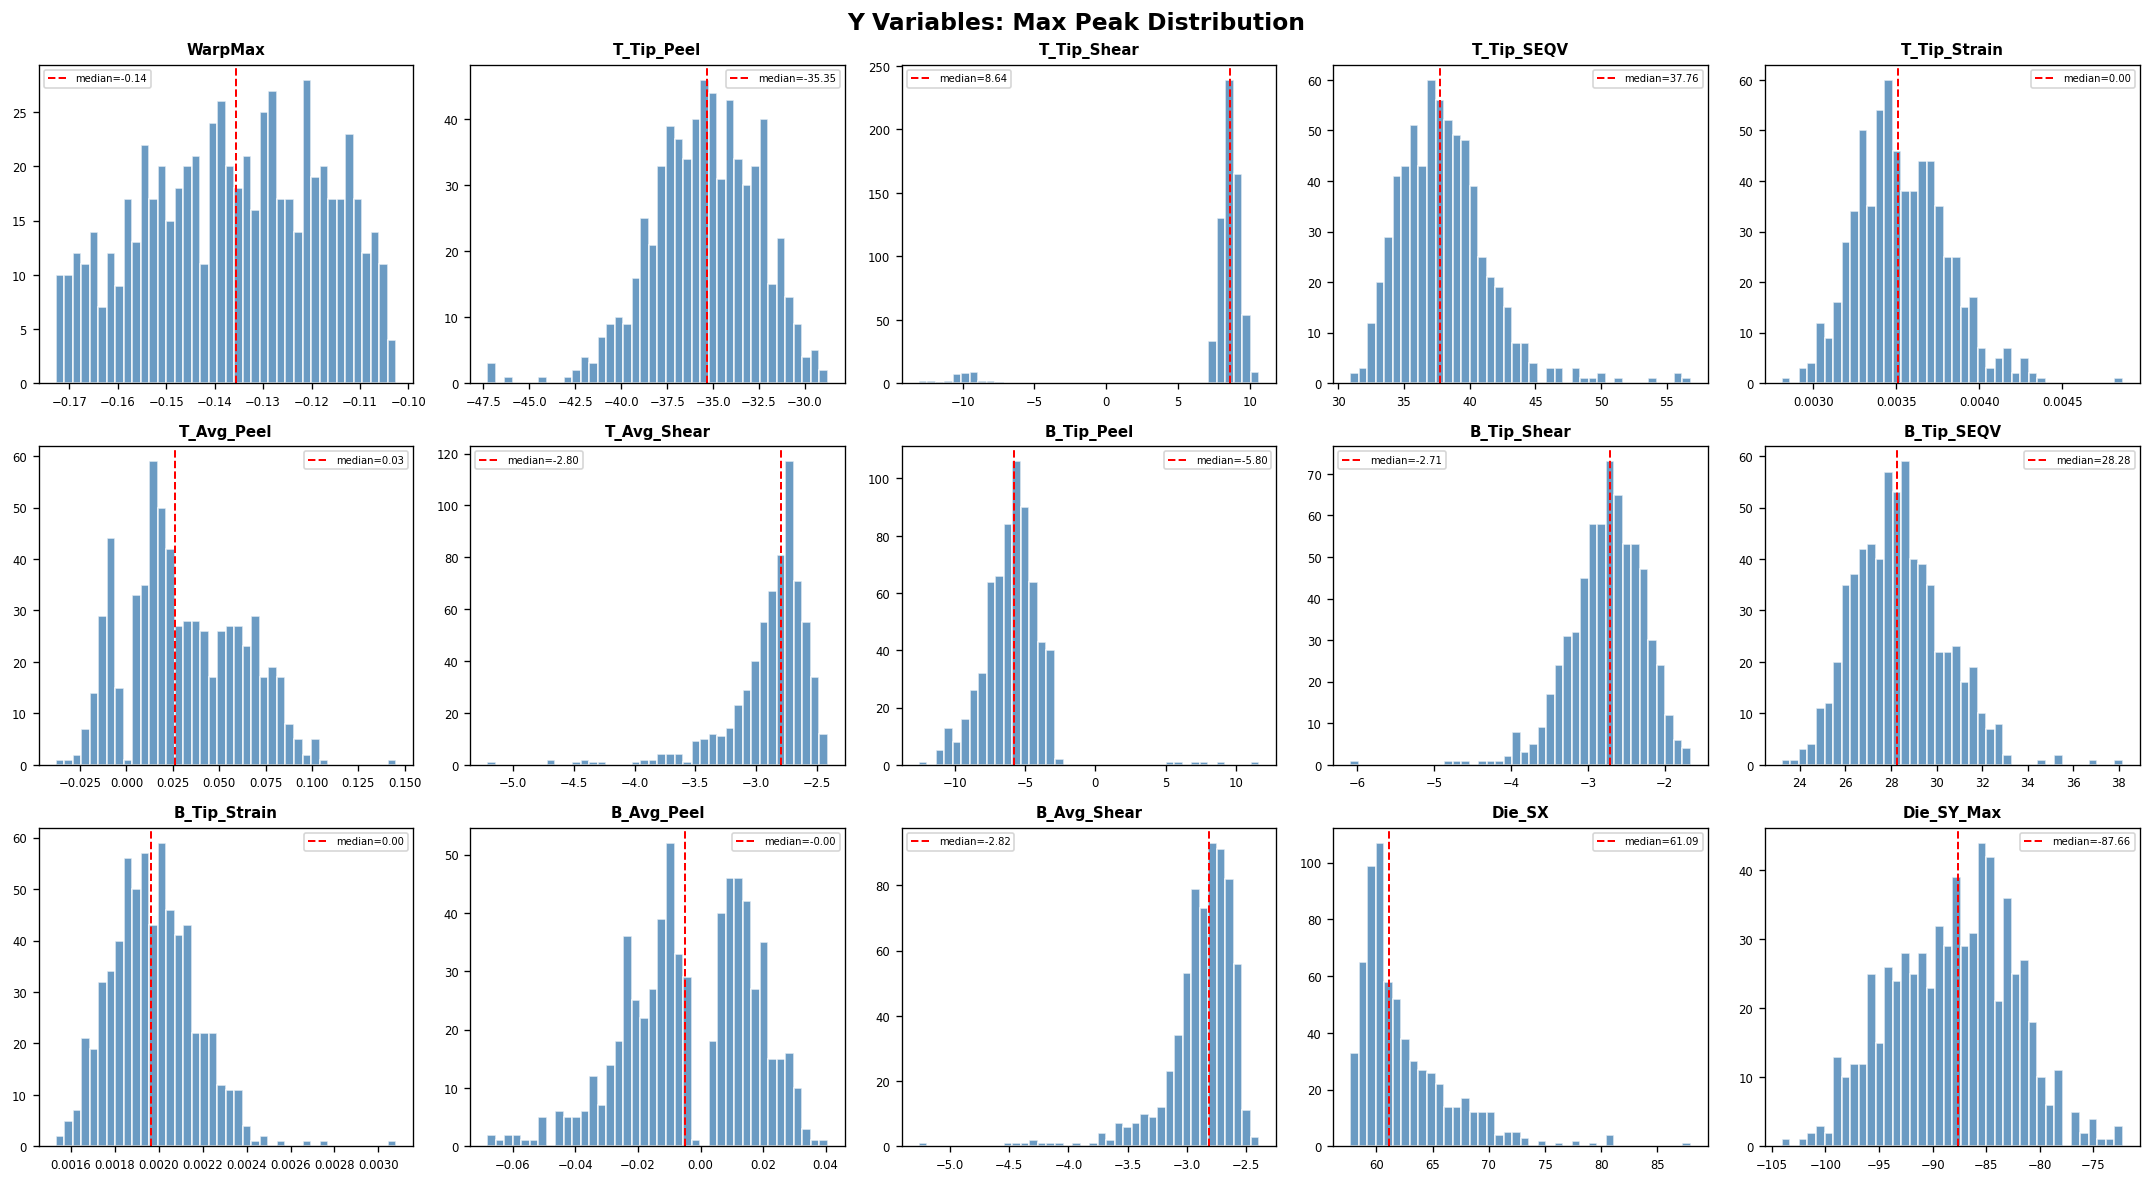

In [29]:
# == 3-2. Y 변수 피크값 분포 히스토그램 ==
# 각 응력/변형 채널의 피크 분포를 확인하여 편향(skew)이나 이상치 진단

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Y Variables: Max Peak Distribution', fontsize=14, fontweight='bold')

for idx, y_col in enumerate(Y_COLUMNS):
    ax = axes[idx // 5, idx % 5]
    data = df_peaks[y_col].dropna()
    
    # 히스토그램 + 중앙값 표시
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color='red', linewidth=1.2, linestyle='--',
               label=f'median={data.median():.2f}')
    ax.set_title(y_col, fontsize=9, fontweight='bold')
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

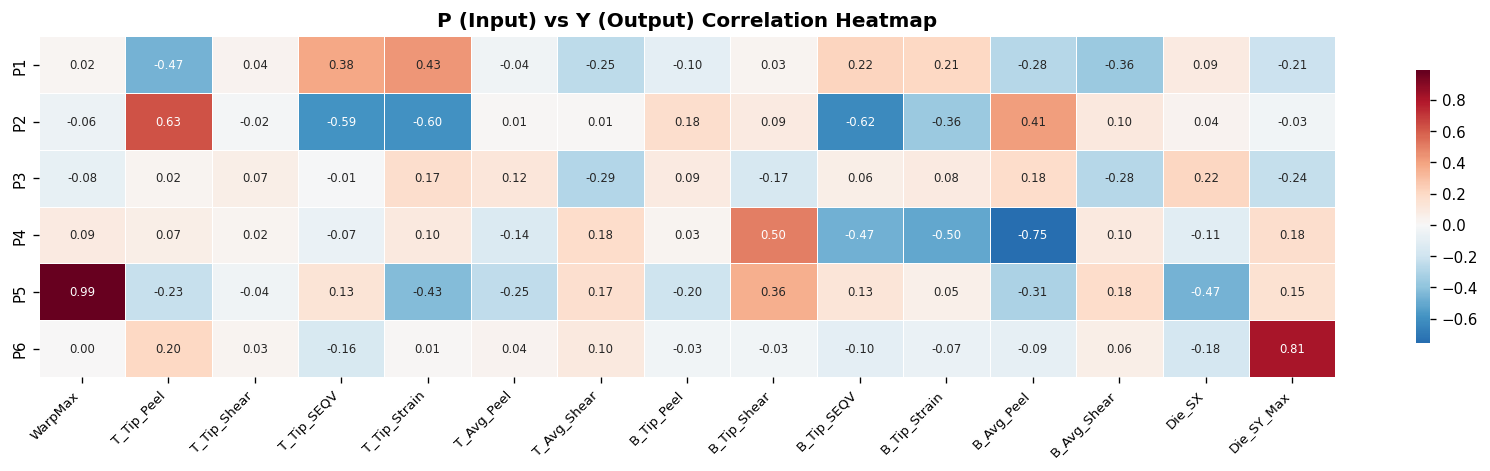


-- |상관계수| > 0.5인 강한 P-Y 관계 --
  P2 -> T_Tip_Peel: r=0.630 (양의 상관)
  P2 -> T_Tip_SEQV: r=-0.588 (음의 상관)
  P2 -> T_Tip_Strain: r=-0.596 (음의 상관)
  P2 -> B_Tip_SEQV: r=-0.624 (음의 상관)
  P4 -> B_Tip_Strain: r=-0.503 (음의 상관)
  P4 -> B_Avg_Peel: r=-0.755 (음의 상관)
  P5 -> WarpMax: r=0.986 (양의 상관)
  P6 -> Die_SY_Max: r=0.813 (양의 상관)


In [30]:
# == 3-3. P(입력) <-> Y(출력) 상관관계 히트맵 ==
# 어떤 두께 변수(P)가 어떤 응력(Y)에 강하게 영향을 미치는지 파악

p_cols = ['P1','P2','P3','P4','P5','P6']
corr_matrix = df_peaks[p_cols + Y_COLUMNS].corr()

# P vs Y 영역만 추출 (6 x 15 부분행렬)
corr_py = corr_matrix.loc[p_cols, Y_COLUMNS]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(corr_py, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
ax.set_title('P (Input) vs Y (Output) Correlation Heatmap', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# 상관관계가 강한 P-Y 조합 출력 (|r| > 0.5)
print('\n-- |상관계수| > 0.5인 강한 P-Y 관계 --')
for p in p_cols:
    for y in Y_COLUMNS:
        r = corr_py.loc[p, y]
        if abs(r) > 0.5:
            direction = '양' if r > 0 else '음'
            print(f'  {p} -> {y}: r={r:.3f} ({direction}의 상관)')

---
## 4. Gaussian Process Regression (GPR) 대리 모델 학습

### XGBoost에서 GPR로 변경한 이유
- XGBoost/LightGBM은 트리 기반 모델로, 학습 데이터 범위 경계에서 **리프 노드 평균값으로 수렴**하여
  분포 양 끝에 비정상적인 뿔(Spike)이 발생함 (구조적 한계, Optuna 튜닝으로도 해결 불가)
- GPR은 **연속 함수**로 예측하므로 경계에서 flat 수렴 없이 부드러운 분포 생성
- 예측값과 함께 **불확실성(σ)**을 출력하여 외삽 영역을 자동 감지 가능
- 데이터가 ~900개인 상황은 GPR의 최적 구간 (수천 개 이상이면 느려짐)

### 커널 선정
- `Matern(nu=2.5)`: 물리 시뮬레이션에 적합 (2차 미분 가능, 매끄러운 응력 곡면)
- `ConstantKernel`: 출력 스케일 자동 조정
- `WhiteKernel`: 관측 노이즈(시뮬레이션 메쉬 오차 등) 흡수

### 학습 전략
- 타겟별 개별 GPR 학습 (15개 독립 모델)
- **StandardScaler** 적용: GPR은 입력 스케일에 민감하므로 P1~P6를 정규화
- 5-Fold CV + 홀드아웃 Test로 성능 이중 검증

In [31]:
# == 4-1. X / Y 분리 및 Train / Test Split ==

X = df_peaks[['P1','P2','P3','P4','P5','P6']].copy()  # 입력: 6개 두께 변수
Y = df_peaks[Y_COLUMNS].copy()                         # 출력: 15개 응력/변형 피크

# 홀드아웃 테스트셋 15% 분리
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.15, random_state=SEED
)

# GPR은 입력 스케일에 민감 → StandardScaler로 P1~P6 정규화
# P1(0.80~1.10)과 P6(0.04~0.08)의 스케일 차이가 크므로 반드시 필요
scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)   # 학습 데이터 기준 fit + transform
X_test_sc  = scaler_X.transform(X_test)         # 테스트 데이터는 transform만

print(f'전체 데이터: {len(X)}개')
print(f'  +-- Train : {len(X_train)}개 (GPR 학습 + 5-Fold CV)')
print(f'  +-- Test  : {len(X_test)}개 (최종 성능 평가, 학습에 미사용)')
print(f'\\nStandardScaler 적용 완료 (GPR 입력 정규화)')

전체 데이터: 666개
  +-- Train : 566개 (GPR 학습 + 5-Fold CV)
  +-- Test  : 100개 (최종 성능 평가, 학습에 미사용)
\nStandardScaler 적용 완료 (GPR 입력 정규화)


In [32]:
# == 4-2. 타겟별 개별 GPR 학습 ==
# 15개 Y 변수 각각에 대해 독립적인 Gaussian Process 모델을 학습
# GPR은 연속 함수로 예측하므로 트리 모델의 양 끝단 뿔(Spike) 현상이 발생하지 않음

# ARD 커널: length_scale을 6개(P1~P6 각각)로 독립 할당
# → 학습 후 각 변수별 length_scale이 다른 값으로 수렴
# → length_scale이 작은 변수 = 민감도 높음 = 중요한 변수
kernel_base = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * Matern(
        nu=2.5,
        length_scale=np.ones(6),              # 6개 독립 length_scale 초기값
        length_scale_bounds=(1e-2, 1e2)
    )
    + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e1))
)

# 학습 결과 저장용 딕셔너리
models = {}          # {y_col: fitted GaussianProcessRegressor}
cv_scores = {}       # {y_col: mean 5-Fold CV R2}
test_scores = {}     # {y_col: holdout test R2}
test_maes = {}       # {y_col: holdout test MAE}

print('=== 타겟별 GPR 학습 시작 ===')
print(f'커널: ConstantKernel * Matern(nu=2.5) + WhiteKernel')
print(f'학습 데이터: {len(X_train)}개 (스케일링 적용)')
print()

t_start = time.time()

for y_col in Y_COLUMNS:
    # -- 개별 GPR 모델 생성 및 학습 --
    gpr = GaussianProcessRegressor(
        kernel=kernel_base,
        n_restarts_optimizer=10,  # 커널 하이퍼파라미터 최적화를 10회 반복 (로컬 최적 회피)
        alpha=1e-6,               # 수치 안정성을 위한 대각 정규화
        random_state=SEED
    )
    
    gpr.fit(X_train_sc, Y_train[y_col])
    
    # -- 5-Fold 교차검증 (과적합 진단용) --
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_r2 = cross_val_score(
        GaussianProcessRegressor(
            kernel=kernel_base,
            n_restarts_optimizer=5,   # CV에서는 속도를 위해 5회로 축소
            alpha=1e-6,
            random_state=SEED
        ),
        X_train_sc, Y_train[y_col],
        cv=kf, scoring='r2'
    )
    
    # -- 홀드아웃 테스트 평가 --
    y_pred_test, y_std_test = gpr.predict(X_test_sc, return_std=True)
    
    # 물리적 음수 방지: SEQV, Strain은 정의상 항상 >= 0
    if y_col in POSITIVE_ONLY_COLS:
        y_pred_test = np.clip(y_pred_test, 0, None)
    
    r2_test = r2_score(Y_test[y_col], y_pred_test)
    mae_test = mean_absolute_error(Y_test[y_col], y_pred_test)
    
    # 결과 저장
    models[y_col] = gpr
    cv_scores[y_col] = cv_r2.mean()
    test_scores[y_col] = r2_test
    test_maes[y_col] = mae_test
    
    # 과적합 경고
    gap = abs(cv_r2.mean() - r2_test)
    flag = '  << OVERFIT?' if gap > 0.10 else ''
    
    print(f'{y_col:15s} | CV R2={cv_r2.mean():.4f} (+-{cv_r2.std():.4f}) | '
          f'Test R2={r2_test:.4f} | MAE={mae_test:.4f} | '
          f'mean_std={y_std_test.mean():.4f}{flag}')

elapsed = time.time() - t_start
print(f'\\n=== 전체 학습 완료 ({elapsed:.1f}초 소요) ===')

avg_cv = np.mean(list(cv_scores.values()))
avg_test = np.mean(list(test_scores.values()))
print(f'평균 CV R2: {avg_cv:.4f} / 평균 Test R2: {avg_test:.4f}')

=== 타겟별 GPR 학습 시작 ===
커널: ConstantKernel * Matern(nu=2.5) + WhiteKernel
학습 데이터: 566개 (스케일링 적용)

WarpMax         | CV R2=0.9993 (+-0.0004) | Test R2=0.9988 | MAE=0.0003 | mean_std=0.0032
T_Tip_Peel      | CV R2=0.7029 (+-0.0721) | Test R2=0.7727 | MAE=0.9212 | mean_std=1.5452
T_Tip_Shear     | CV R2=-0.1865 (+-0.2083) | Test R2=-0.0909 | MAE=2.1946 | mean_std=3.7357
T_Tip_SEQV      | CV R2=0.5150 (+-0.0762) | Test R2=0.5878 | MAE=1.2611 | mean_std=2.3369
T_Tip_Strain    | CV R2=0.7994 (+-0.0383) | Test R2=0.7977 | MAE=0.0001 | mean_std=0.0032
T_Avg_Peel      | CV R2=0.0442 (+-0.0558) | Test R2=0.0628 | MAE=0.0256 | mean_std=0.0293
T_Avg_Shear     | CV R2=0.2115 (+-0.0356) | Test R2=0.1979 | MAE=0.1972 | mean_std=0.2873
B_Tip_Peel      | CV R2=0.0561 (+-0.0854) | Test R2=0.0149 | MAE=1.3367 | mean_std=1.9929
B_Tip_Shear     | CV R2=0.4305 (+-0.0597) | Test R2=0.4024 | MAE=0.2962 | mean_std=0.3616
B_Tip_SEQV      | CV R2=0.8195 (+-0.0731) | Test R2=0.8287 | MAE=0.5723 | mean_std=0.8254
B_

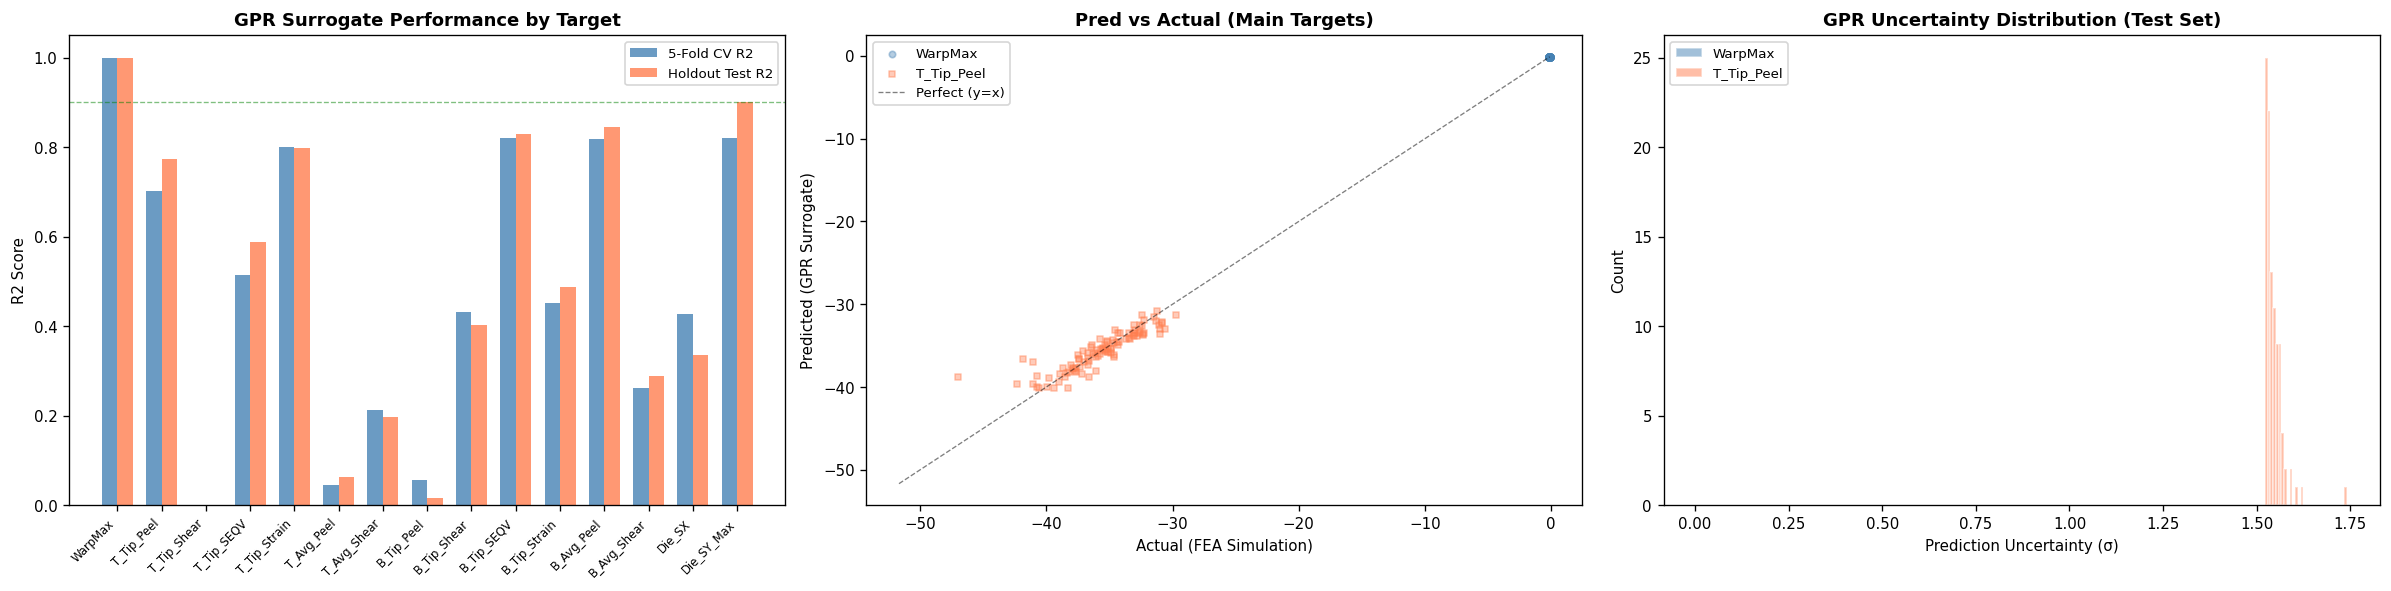

In [33]:
# == 4-3. 모델 성능 시각화 ==

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- (A) 변수별 R2 비교 바 차트 (CV vs Test) ---
ax = axes[0]
x_pos = np.arange(len(Y_COLUMNS))
width = 0.35

ax.bar(x_pos - width/2, [cv_scores[c] for c in Y_COLUMNS], width,
       label='5-Fold CV R2', color='steelblue', alpha=0.8)
ax.bar(x_pos + width/2, [test_scores[c] for c in Y_COLUMNS], width,
       label='Holdout Test R2', color='coral', alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels(Y_COLUMNS, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('R2 Score')
ax.set_title('GPR Surrogate Performance by Target', fontweight='bold')
ax.legend(fontsize=8)
ax.axhline(0.9, color='green', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_ylim(0, 1.05)

# --- (B) Pred vs Actual 산점도 (메인 타겟 2개) ---
ax = axes[1]
for y_col, color, marker in [('WarpMax', 'steelblue', 'o'), ('T_Tip_Peel', 'coral', 's')]:
    y_actual = Y_test[y_col].values
    y_pred, y_std = models[y_col].predict(X_test_sc, return_std=True)
    if y_col in POSITIVE_ONLY_COLS:
        y_pred = np.clip(y_pred, 0, None)
    ax.scatter(y_actual, y_pred, alpha=0.4, s=15, c=color, marker=marker, label=y_col)

all_vals = np.concatenate([Y_test['WarpMax'].values, Y_test['T_Tip_Peel'].values])
lims = [all_vals.min() * 1.1, all_vals.max() * 1.1]
ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5, label='Perfect (y=x)')
ax.set_xlabel('Actual (FEA Simulation)')
ax.set_ylabel('Predicted (GPR Surrogate)')
ax.set_title('Pred vs Actual (Main Targets)', fontweight='bold')
ax.legend(fontsize=8)

# --- (C) GPR 불확실성(σ) 분포 (GPR 고유 장점) ---
# 불확실성이 높은 예측 = 외삽 영역 → 신뢰도 낮음
ax = axes[2]
for y_col, color in [('WarpMax', 'steelblue'), ('T_Tip_Peel', 'coral')]:
    _, y_std = models[y_col].predict(X_test_sc, return_std=True)
    ax.hist(y_std, bins=30, alpha=0.5, color=color, edgecolor='white', label=y_col)
ax.set_xlabel('Prediction Uncertainty (σ)')
ax.set_ylabel('Count')
ax.set_title('GPR Uncertainty Distribution (Test Set)', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

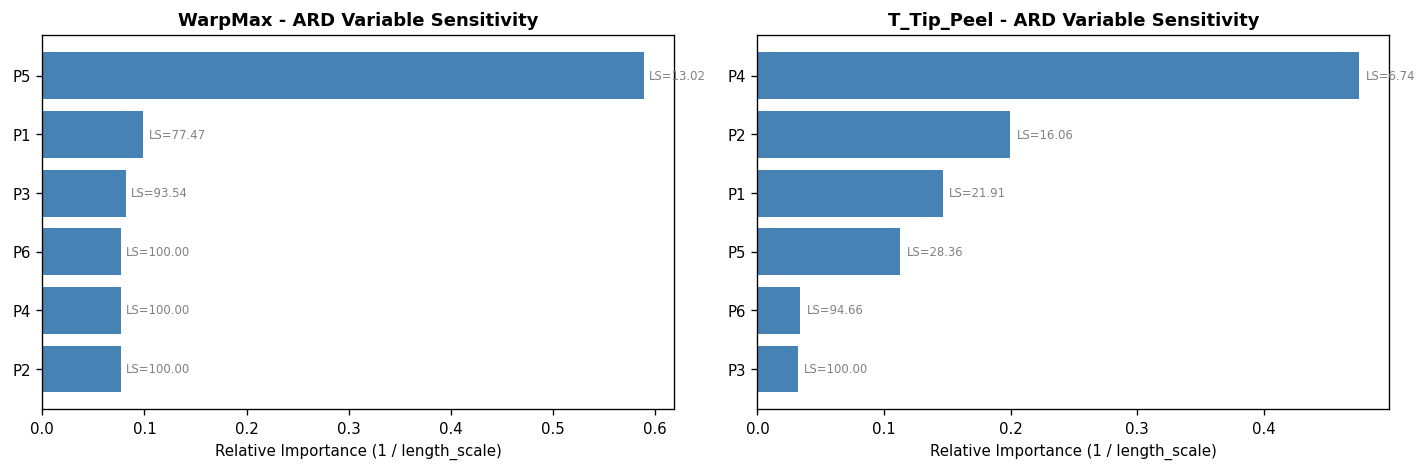


WarpMax 학습된 length_scale:
  P1: 77.4717 (중요도 ∝ 1/77.4717 = 0.0129)
  P2: 100.0000 (중요도 ∝ 1/100.0000 = 0.0100)
  P3: 93.5439 (중요도 ∝ 1/93.5439 = 0.0107)
  P4: 100.0000 (중요도 ∝ 1/100.0000 = 0.0100)
  P5: 13.0203 (중요도 ∝ 1/13.0203 = 0.0768)
  P6: 100.0000 (중요도 ∝ 1/100.0000 = 0.0100)

T_Tip_Peel 학습된 length_scale:
  P1: 21.9144 (중요도 ∝ 1/21.9144 = 0.0456)
  P2: 16.0560 (중요도 ∝ 1/16.0560 = 0.0623)
  P3: 100.0000 (중요도 ∝ 1/100.0000 = 0.0100)
  P4: 6.7433 (중요도 ∝ 1/6.7433 = 0.1483)
  P5: 28.3554 (중요도 ∝ 1/28.3554 = 0.0353)
  P6: 94.6604 (중요도 ∝ 1/94.6604 = 0.0106)


In [34]:
# == 4-4. GPR 기반 변수 중요도 (ARD 커널 Length Scale) ==
# ARD Matern 커널이 변수별로 학습한 length_scale의 역수 = 변수 민감도
# length_scale이 작을수록 → 해당 변수의 작은 변화에도 출력이 크게 반응 → 중요도 높음

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_col in zip(axes, ['WarpMax', 'T_Tip_Peel']):
    learned_kernel = models[y_col].kernel_
    matern_kernel = learned_kernel.k1.k2  # ConstantKernel * Matern 중 Matern 추출
    length_scales = np.array(matern_kernel.length_scale)
    
    # 역수 → 정규화하여 상대 중요도로 변환
    importance = 1.0 / length_scales
    importance = importance / importance.sum()
    
    # 중요도 내림차순 정렬
    p_labels = ['P1','P2','P3','P4','P5','P6']
    sorted_idx = np.argsort(importance)
    sorted_labels = [p_labels[i] for i in sorted_idx]
    sorted_importance = importance[sorted_idx]
    
    ax.barh(sorted_labels, sorted_importance, color='steelblue')
    ax.set_xlabel('Relative Importance (1 / length_scale)')
    ax.set_title(f'{y_col} - ARD Variable Sensitivity', fontweight='bold')
    
    # 각 변수의 실제 length_scale 값도 표시
    for i, (label, imp) in enumerate(zip(sorted_labels, sorted_importance)):
        ls_val = length_scales[p_labels.index(label)]
        ax.text(imp + 0.005, i, f'LS={ls_val:.2f}', va='center', fontsize=7, color='gray')

plt.tight_layout()
plt.show()

# 학습된 length_scale 상세 출력
for y_col in ['WarpMax', 'T_Tip_Peel']:
    ls = models[y_col].kernel_.k1.k2.length_scale
    print(f'\n{y_col} 학습된 length_scale:')
    for p, l in zip(['P1','P2','P3','P4','P5','P6'], ls):
        print(f'  {p}: {l:.4f} (중요도 ∝ 1/{l:.4f} = {1/l:.4f})')

---
## 5. 몬테카를로 난수 생성 및 10만 개 가상 데이터 증강

학습된 XGBoost 대리 모델로 **10만 개의 가상 P1~P6 조합**에 대한 Y값을 예측합니다.

### 난수 생성 방식: Latin Hypercube Sampling (LHS)
- 단순 `np.random.uniform`보다 6차원 설계 공간을 **더 균일하게 커버**
- 각 차원을 N개 구간으로 분할 후 구간당 1개씩 배치 (층화 샘플링)
- 동일 샘플 수 대비 사각지대(dead zone) 없이 골고루 분포

In [35]:
# == 5-1. Latin Hypercube Sampling (LHS)으로 10만 개 P1~P6 생성 ==

N_VIRTUAL = 100_000  # 생성할 가상 데이터 수

def latin_hypercube_sampling(n_samples, n_dims, seed=42):
    """
    Latin Hypercube Sampling (LHS) 구현
    
    원리:
    - [0, 1] 범위를 n_samples개의 균등 구간으로 분할
    - 각 차원에서 한 구간당 정확히 하나의 샘플을 배치 (층화 샘플링)
    - 차원별로 독립적으로 셔플하여 조합
    
    Parameters:
        n_samples: 생성할 샘플 수
        n_dims: 차원 수 (변수 수)
        seed: 난수 시드
    Returns:
        (n_samples, n_dims) numpy 배열, 값 범위 [0, 1]
    """
    rng = np.random.RandomState(seed)
    result = np.zeros((n_samples, n_dims))
    
    for dim in range(n_dims):
        # 각 구간 내에서의 랜덤 오프셋 생성
        perms = rng.permutation(n_samples)  # 구간 순서 셔플
        # (구간 번호 + 랜덤 오프셋) / 총 구간 수 -> [0, 1] 범위로 정규화
        result[:, dim] = (perms + rng.uniform(size=n_samples)) / n_samples
    
    return result

# [0,1]^6 범위 LHS 생성
lhs_raw = latin_hypercube_sampling(N_VIRTUAL, n_dims=6, seed=SEED)

# 각 P 변수의 실제 min/max 바운더리로 스케일링
# 바운더리는 마스터 DOE 전체 1200개 기준 (생존 데이터가 아닌 원본 전체)
p_cols = ['P1','P2','P3','P4','P5','P6']
virtual_X_dict = {}

print(f'-- {N_VIRTUAL:,}개 가상 P1~P6 생성 (LHS) --')
print(f'{"변수":>5s} | {"Min":>8s} | {"Max":>8s}')
print('-' * 30)

for i, p in enumerate(p_cols):
    lo = df_master[p].min()   # 마스터 DOE 전체의 최솟값
    hi = df_master[p].max()   # 마스터 DOE 전체의 최댓값
    
    # [0,1] -> [min, max] 선형 변환
    virtual_X_dict[p] = lo + (hi - lo) * lhs_raw[:, i]
    print(f'{p:>5s} | {lo:8.4f} | {hi:8.4f}')

df_virtual_X = pd.DataFrame(virtual_X_dict)
print(f'\n{N_VIRTUAL:,}개 가상 P1~P6 조합 생성 완료')
display(df_virtual_X.describe().round(4))

-- 100,000개 가상 P1~P6 생성 (LHS) --
   변수 |      Min |      Max
------------------------------
   P1 |   0.8005 |   1.0998
   P2 |   0.0500 |   0.0899
   P3 |   0.6001 |   0.7198
   P4 |   0.1000 |   0.2994
   P5 |   1.2003 |   1.7997
   P6 |   0.0401 |   0.0800

100,000개 가상 P1~P6 조합 생성 완료


,P1,P2,P3,P4,P5,P6
count,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000
mean,0.9502,0.0699,0.6600,0.1997,1.5000,0.0600
std,0.0864,0.0115,0.0346,0.0576,0.1730,0.0115
min,0.8005,0.0500,0.6001,0.1000,1.2003,0.0401
25%,0.8753,0.0600,0.6300,0.1499,1.3502,0.0501
50%,0.9502,0.0700,0.6599,0.1997,1.5000,0.0600
75%,1.0250,0.0799,0.6899,0.2495,1.6498,0.0700
max,1.0998,0.0899,0.7198,0.2994,1.7997,0.0800


In [36]:
# == 5-2. GPR 대리 모델로 10만 개 Y값 예측 ==

# 가상 P1~P6도 동일한 StandardScaler로 변환
X_virtual_sc = scaler_X.transform(df_virtual_X)

print(f'학습된 GPR로 {N_VIRTUAL:,}개의 Y 값 예측 중...')
print('(GPR 예측은 XGBoost보다 느릴 수 있음, 타겟당 수 초~수십 초 소요)')
t_start = time.time()

virtual_Y_dict = {}
virtual_std_dict = {}  # 불확실성도 함께 저장

for y_col in Y_COLUMNS:
    t_col = time.time()
    
    # GPR 예측: 평균값 + 불확실성(σ)
    y_pred, y_std = models[y_col].predict(X_virtual_sc, return_std=True)
    
    # 물리적 음수 방지: SEQV, Strain은 정의상 항상 >= 0
    if y_col in POSITIVE_ONLY_COLS:
        y_pred = np.clip(y_pred, 0, None)
    
    virtual_Y_dict[y_col] = y_pred
    virtual_std_dict[y_col + '_std'] = y_std
    
    print(f'  {y_col:15s} 완료 ({time.time()-t_col:.1f}초) | '
          f'mean_std={y_std.mean():.4f}, max_std={y_std.max():.4f}')

df_virtual_Y = pd.DataFrame(virtual_Y_dict)
df_virtual_std = pd.DataFrame(virtual_std_dict)  # 불확실성 별도 저장 (선택적 활용)

elapsed = time.time() - t_start
print(f'\\n예측 완료! (총 {elapsed:.1f}초 소요)')
print(f'평균 불확실성(σ)이 높은 상위 3개 변수:')
mean_stds = {col: df_virtual_std[col+'_std'].mean() for col in Y_COLUMNS}
for col, std in sorted(mean_stds.items(), key=lambda x: x[1], reverse=True)[:3]:
    print(f'  {col}: mean σ = {std:.4f}')

학습된 GPR로 100,000개의 Y 값 예측 중...
(GPR 예측은 XGBoost보다 느릴 수 있음, 타겟당 수 초~수십 초 소요)
  WarpMax         완료 (1.5초) | mean_std=0.0032, max_std=0.0035
  T_Tip_Peel      완료 (1.1초) | mean_std=1.5686, max_std=2.1463
  T_Tip_Shear     완료 (3.6초) | mean_std=3.8559, max_std=5.5069
  T_Tip_SEQV      완료 (1.1초) | mean_std=2.3452, max_std=2.5532
  T_Tip_Strain    완료 (1.2초) | mean_std=0.0032, max_std=0.0032
  T_Avg_Peel      완료 (1.0초) | mean_std=0.0294, max_std=0.0300
  T_Avg_Shear     완료 (1.2초) | mean_std=0.2879, max_std=0.3047
  B_Tip_Peel      완료 (1.0초) | mean_std=2.0408, max_std=2.9495
  B_Tip_Shear     완료 (1.1초) | mean_std=0.3632, max_std=0.3972
  B_Tip_SEQV      완료 (1.1초) | mean_std=0.8321, max_std=0.9805
  B_Tip_Strain    완료 (1.2초) | mean_std=0.0032, max_std=0.0032
  B_Avg_Peel      완료 (1.0초) | mean_std=0.0084, max_std=0.0104
  B_Avg_Shear     완료 (1.1초) | mean_std=0.2530, max_std=0.2650
  Die_SX          완료 (1.1초) | mean_std=3.0721, max_std=3.3803
  Die_SY_Max      완료 (1.3초) | mean_std=2.3420, max_std=3

In [37]:
# == 5-3. 예측 결과 물리적 범위 검증 ==
# 대리 모델이 외삽(extrapolation)하여 비현실적인 값을 예측했는지 검증
# 실제 데이터 범위 +- 20% 마진을 허용 범위로 설정

print('=== 예측 데이터 물리적 범위 검증 ===')
print(f'{"변수":15s} | {"실제 Min":>12s} | {"실제 Max":>12s} | '
      f'{"예측 Min":>12s} | {"예측 Max":>12s} | 이탈률')
print('-' * 90)

outlier_flags = pd.Series(False, index=df_virtual_Y.index)

for y_col in Y_COLUMNS:
    actual_min = df_peaks[y_col].min()
    actual_max = df_peaks[y_col].max()
    pred_min = df_virtual_Y[y_col].min()
    pred_max = df_virtual_Y[y_col].max()
    
    # 실제 범위의 20% 마진을 허용 범위로 설정
    margin = (actual_max - actual_min) * 0.20
    safe_lo = actual_min - margin
    safe_hi = actual_max + margin
    
    # 허용 범위를 벗어나는 예측값 탐지
    out_mask = (df_virtual_Y[y_col] < safe_lo) | (df_virtual_Y[y_col] > safe_hi)
    outlier_flags = outlier_flags | out_mask
    n_out = out_mask.sum()
    pct = n_out / len(df_virtual_Y) * 100
    
    flag = '  <<' if pct > 5 else ''
    print(f'{y_col:15s} | {actual_min:12.4f} | {actual_max:12.4f} | '
          f'{pred_min:12.4f} | {pred_max:12.4f} | {pct:5.2f}%{flag}')

n_outlier = outlier_flags.sum()
print(f'\n범위 이탈 샘플 총합: {n_outlier:,}개 ({n_outlier/len(df_virtual_Y)*100:.2f}%)')
print('(이탈 샘플이 많으면 모델 과적합 또는 외삽 위험)')
print('-> Step 2 Gatekeeper 분류기에서 물리적으로 불안전한 조합은 추가 필터링 예정')

=== 예측 데이터 물리적 범위 검증 ===
변수              |       실제 Min |       실제 Max |       예측 Min |       예측 Max | 이탈률
------------------------------------------------------------------------------------------
WarpMax         |      -0.1728 |      -0.1025 |      -0.1778 |      -0.0979 |  0.00%
T_Tip_Peel      |     -47.2917 |     -28.7603 |     -43.0122 |     -27.3046 |  0.00%
T_Tip_Shear     |     -13.0566 |      10.6679 |      -7.1867 |      10.7624 |  0.00%
T_Tip_SEQV      |      30.9377 |      56.8349 |      31.4024 |      45.5277 |  0.00%
T_Tip_Strain    |       0.0028 |       0.0049 |       0.0028 |       0.0043 |  0.00%
T_Avg_Peel      |      -0.0382 |       0.1454 |       0.0016 |       0.0464 |  0.00%
T_Avg_Shear     |      -5.2160 |      -2.4083 |      -3.6717 |      -2.4950 |  0.00%
B_Tip_Peel      |     -12.5674 |      11.6636 |      -9.0552 |       0.1573 |  0.00%
B_Tip_Shear     |      -6.0878 |      -1.6600 |      -3.8885 |      -1.6438 |  0.00%
B_Tip_SEQV      |      23.2101 |     

In [38]:
# == 5-4. 증강 데이터 병합 및 CSV 저장 ==

# X(입력: P1~P6)와 예측된 Y(출력: 15개 응력/변형 피크) 병합
df_augmented = pd.concat([df_virtual_X, df_virtual_Y], axis=1)

# 가상 데이터 식별용 ID 부여 (원본과 구분)
df_augmented.insert(0, 'Row_ID', [f'Virtual_{i+1}' for i in range(N_VIRTUAL)])

# CSV 저장
output_file = 'Augmented_100k_Data.csv'
df_augmented.to_csv(output_file, index=False)

print(f'=== 증강 데이터 저장 완료 ===')
print(f'파일명: {output_file}')
print(f'크기: {df_augmented.shape[0]:,}행 x {df_augmented.shape[1]}열')
print(f'컬럼: Row_ID + P1~P6 (6) + Y변수 ({len(Y_COLUMNS)}) = {1+6+len(Y_COLUMNS)}열')
print()
display(df_augmented.head())

=== 증강 데이터 저장 완료 ===
파일명: Augmented_100k_Data.csv
크기: 100,000행 x 22열
컬럼: Row_ID + P1~P6 (6) + Y변수 (15) = 22열



,Row_ID,P1,P2,P3,P4,P5,P6,WarpMax,T_Tip_Peel,T_Tip_Shear,...,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
0,Virtual_1,1.027135,0.087445,0.658718,0.231420,1.685991,0.052563,-0.116172,-34.254066,5.862142,...,0.014998,-2.868502,-5.505438,-2.110559,24.925584,0.001802,-0.018232,-2.867465,61.134654,-91.604811
1,Virtual_2,1.040493,0.076397,0.628455,0.214296,1.579394,0.077707,-0.123429,-34.306625,8.666138,...,0.023529,-2.779966,-6.192873,-2.340398,26.582110,0.001893,-0.020535,-2.838806,60.296626,-81.411228
2,Virtual_3,0.859955,0.086767,0.655392,0.189343,1.779187,0.066959,-0.104578,-32.805252,7.693487,...,0.015150,-2.780815,-5.182477,-2.492546,27.073971,0.001817,-0.001829,-2.689904,59.911051,-81.523369
3,Virtual_4,1.030061,0.065772,0.626600,0.236199,1.400582,0.046464,-0.144752,-37.858084,8.076575,...,0.028498,-2.949231,-5.246300,-2.488714,27.906931,0.001927,-0.026798,-2.987525,63.363203,-96.726933
4,Virtual_5,1.078823,0.057586,0.608553,0.295215,1.325479,0.077874,-0.150512,-37.262825,6.307168,...,0.026406,-2.865443,-5.669283,-2.408596,27.467005,0.001864,-0.048530,-3.002332,61.433085,-81.929107


---
## 6. 증강 데이터 품질 검증 (Sanity Check)

증강된 10만 개 데이터의 분포가 원본 ~900개와 일관성이 있는지 시각적으로 검증합니다.

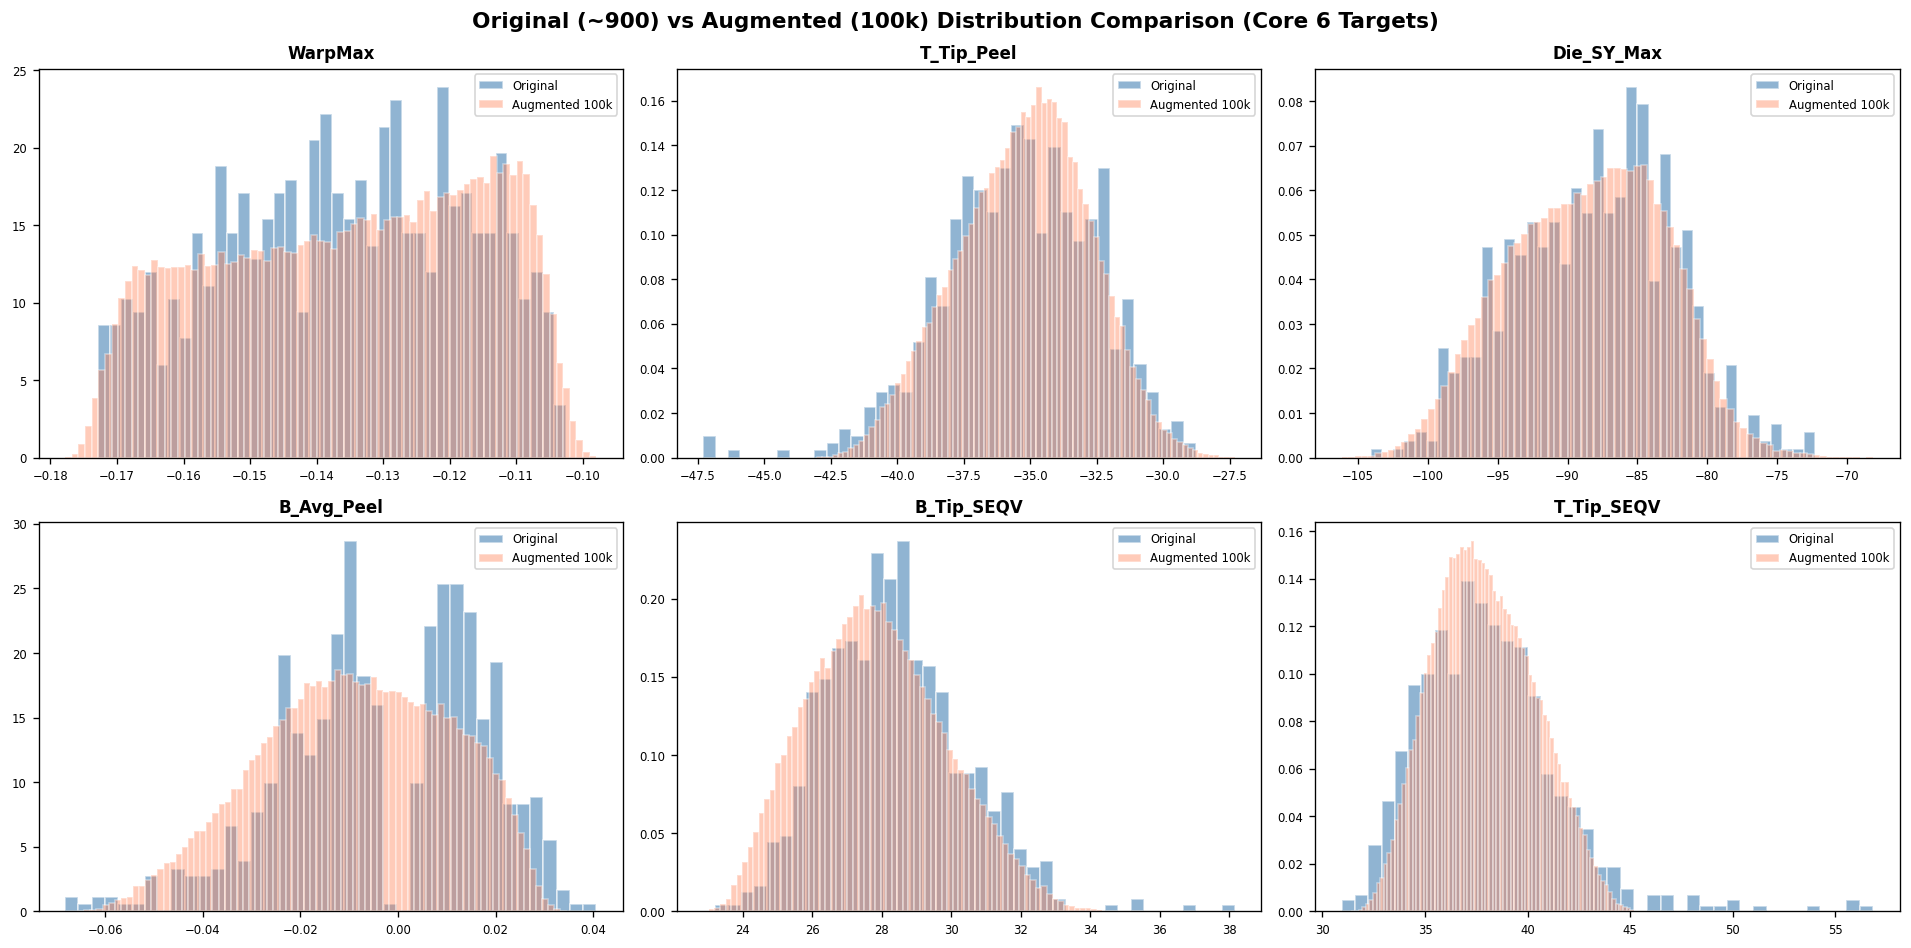

* 분포가 대체로 일치하면 -> 대리 모델이 원본 경향을 잘 학습한 것
* 분포가 크게 다르면 -> 과적합/외삽 위험 -> 하이퍼파라미터 재조정 필요
* (참고: 증강 데이터 양 끝단의 비정상적인 뿔(Spike)은 Step 2 Gatekeeper에서 제거됩니다.)


In [39]:
# == 6-1. 원본 vs 증강 분포 비교 (주요 6대 핵심 변수) ==

# R2 점수가 검증된 6대 핵심 타겟으로 변경 (노이즈 변수 배제)
check_cols = ['WarpMax', 'T_Tip_Peel', 'Die_SY_Max', 
              'B_Avg_Peel', 'B_Tip_SEQV', 'T_Tip_SEQV']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Original (~900) vs Augmented (100k) Distribution Comparison (Core 6 Targets)',
             fontsize=13, fontweight='bold')

for idx, y_col in enumerate(check_cols):
    ax = axes[idx // 3, idx % 3]
    
    # 원본 데이터 분포 (파란색 히스토그램)
    ax.hist(df_peaks[y_col], bins=40, density=True, alpha=0.6,
            color='steelblue', edgecolor='white', label='Original')
    
    # 증강 데이터 분포 (빨간색 히스토그램, 더 세밀한 bin)
    ax.hist(df_augmented[y_col], bins=80, density=True, alpha=0.4,
            color='coral', edgecolor='white', label='Augmented 100k')
    
    ax.set_title(y_col, fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

print('* 분포가 대체로 일치하면 -> 대리 모델이 원본 경향을 잘 학습한 것')
print('* 분포가 크게 다르면 -> 과적합/외삽 위험 -> 하이퍼파라미터 재조정 필요')
print('* (참고: 증강 데이터 양 끝단의 비정상적인 뿔(Spike)은 Step 2 Gatekeeper에서 제거됩니다.)')

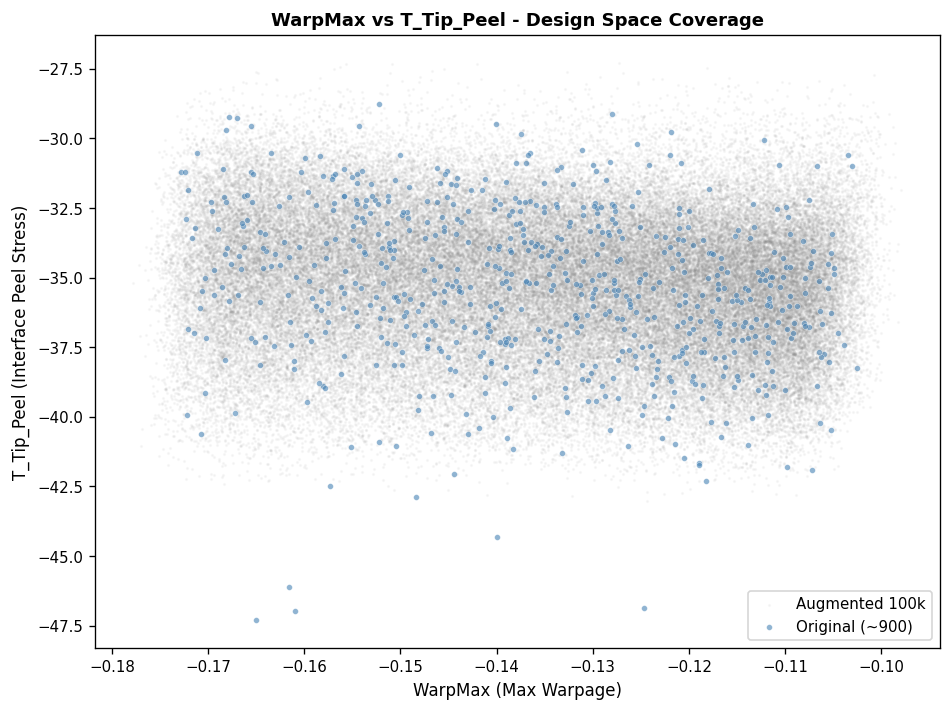

-> 이 2D 공간에서 좌측 하단(WarpMax 작고, T_Tip_Peel 작은)이 이상적인 설계
-> Step 3에서 파레토 프론티어(비지배 해 집합)를 추출할 영역


In [40]:
# == 6-2. 메인 타겟 2D 산점도 (WarpMax vs T_Tip_Peel) ==
# Step 3 파레토 프론티어에서 사용할 두 축의 공간 분포 확인

fig, ax = plt.subplots(figsize=(8, 6))

# 증강 데이터 (배경: 회색, 매우 투명하게)
ax.scatter(df_augmented['WarpMax'], df_augmented['T_Tip_Peel'],
           s=1, alpha=0.05, c='gray', label='Augmented 100k')

# 원본 데이터 (전경: 파란색, 선명하게)
ax.scatter(df_peaks['WarpMax'], df_peaks['T_Tip_Peel'],
           s=12, alpha=0.6, c='steelblue', edgecolors='white',
           linewidths=0.3, label='Original (~900)')

ax.set_xlabel('WarpMax (Max Warpage)', fontsize=10)
ax.set_ylabel('T_Tip_Peel (Interface Peel Stress)', fontsize=10)
ax.set_title('WarpMax vs T_Tip_Peel - Design Space Coverage', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('-> 이 2D 공간에서 좌측 하단(WarpMax 작고, T_Tip_Peel 작은)이 이상적인 설계')
print('-> Step 3에서 파레토 프론티어(비지배 해 집합)를 추출할 영역')

---
## Step 1 완료 요약

| 항목 | 결과 |
|------|------|
| 원본 생존 데이터 | ~900개 DP (1200 중 ~71%) |
| 추출 지표 | 15개 Y변수의 절댓값 Max Peak (부호 유지) |
| 대리 모델 | 타겟별 개별 XGBoost (Early Stopping + 5-Fold CV) |
| 증강 데이터 | **100,000개** (`Augmented_100k_Data.csv`) |
| 난수 생성 | Latin Hypercube Sampling (균등 공간 충전) |

## [Step 2] 은닉 제약조건 분류기(Gatekeeper)를 통한 필터링

### 목표
물리적으로 파괴되는(해석이 터지는) 치수 조합을 사전에 걸러낸다.
### 라벨링 로직
시계열 CSV 폴더(`SIM_CSV_DATA`)에서 `ML_DATA_Extract_Row_{Row_ID}.csv`를 스캔하여:
- 파일이 **존재하는** Row_ID → `is_safe = 1` (Safe)
- 파일이 **누락된** Row_ID → `is_safe = 0` (Fail, 시뮬레이션 발산)
전체 DP 수는 폴더 내 **가장 큰 Row_ID**를 기준으로 산정한다.
각 Row_ID는 `Master_DOE_1200.csv`의 행과 1:1 매칭된다.
(CSV 1행 = 헤더, 2행 = Row_ID 1, 3행 = Row_ID 2, ...)
```
Master_DOE_1200.csv 행 매칭:
  2행 (iloc[0]) → Row_ID = 1 → ML_DATA_Extract_Row_1.csv 존재 여부 확인
  3행 (iloc[1]) → Row_ID = 2 → ML_DATA_Extract_Row_2.csv 존재 여부 확인
  ...
```
### 분류기
- **Random Forest** (n_estimators=300, max_depth=7, class_weight='balanced')
- 입력: P1~P6 (6개 두께 변수)
- 출력: 0(Fail) / 1(Safe) 이진 분류
- 성능 평가: 5-Fold Stratified CV (F1, Accuracy) + OOB Score
### 필터링 흐름
```
Augmented_100k_Data.csv (10만 행)
    ↓ P1~P6 추출
    ↓ Gatekeeper predict → 0(Fail) / 1(Safe)
    ↓ Fail(0) 행 삭제
Augmented_Class_Data.csv 저장 → Step 3로 전달
```
### 출력
- `Augmented_Class_Data.csv`: Fail 제거 후 Safe 데이터만 잔존
- 용도: Step 3 파레토 프론티어 추출의 베이스라인 데이터

In [41]:
# Step 1 증강 데이터 입력 / Step 2 필터링 결과 출력 (절대 경로 통일)
AUGMENTED_INPUT  = 'Augmented_100k_Data.csv'
FILTERED_OUTPUT  = 'Augmented_Class_Data.csv'

SEED = 42
np.random.seed(SEED)

print('=== [Step 2] Gatekeeper 분류기 가동 준비 완료 ===')
print(f'현재 감지된 OS  : {platform.system()}')
print(f'시계열 CSV 폴더 : {CSV_FOLDER}')
print(f'마스터 DOE 파일 : {MASTER_CSV}')
print(f'증강 데이터 입력: {AUGMENTED_INPUT}')
print(f'필터링 결과 출력: {FILTERED_OUTPUT}\n')

=== [Step 2] Gatekeeper 분류기 가동 준비 완료 ===
현재 감지된 OS  : Linux
시계열 CSV 폴더 : /mnt/i/ai_model_dev/cfd/SIM_CSV_DATA
마스터 DOE 파일 : /mnt/i/ai_model_dev/cfd/Master_DOE_1200.csv
증강 데이터 입력: Augmented_100k_Data.csv
필터링 결과 출력: Augmented_Class_Data.csv



In [42]:
# ====================================================================
# [2. 실제 해석 결과 기반 생존/파탄 라벨링]
# ====================================================================
# glob으로 해당 폴더의 모든 CSV 파일 탐색
pattern = os.path.join(CSV_FOLDER, 'ML_DATA_Extract_Row_*.csv')
found_files = sorted(glob.glob(pattern))

# 파일명에서 Row_ID 추출
survived_ids = set()
for fpath in found_files:
    fname = os.path.basename(fpath)
    match = re.search(r'Row_(\d+)\.csv', fname)
    if match:
        survived_ids.add(int(match.group(1)))

if not survived_ids:
    raise FileNotFoundError("지정된 경로에서 CSV 파일을 하나도 찾지 못했습니다.")

# 마스터 DOE 데이터 로드
try:
    df_master = pd.read_csv(MASTER_CSV)
except FileNotFoundError:
    raise FileNotFoundError(f"마스터 파일을 찾을 수 없습니다: {MASTER_CSV}")

# 전체 DP 수 = 폴더 내 최대 Row_ID (단, 마스터 DOE 행 수 초과 방지)
max_row_id = min(max(survived_ids), len(df_master))
print(f"라벨링 범위: Row_ID 1 ~ {max_row_id} (마스터 DOE {len(df_master)}행 중)")

# 1번부터 max_row_id까지 라벨링
# Row_ID=1 → df_master.iloc[0] (CSV 1행은 헤더, 2행부터 데이터)
training_data = []
for row_id in range(1, max_row_id + 1):
    idx = row_id - 1  # 0-based 인덱스

    if idx >= len(df_master):
        print(f'[경고] Row_ID={row_id}가 마스터 DOE 범위를 초과 → 스킵')
        continue

    # 생존 여부: 폴더에 해당 CSV가 있으면 1(Safe), 없으면 0(Fail)
    is_safe = 1 if row_id in survived_ids else 0

    row_data = df_master.iloc[idx].to_dict()
    row_data['Row_ID'] = row_id
    row_data['is_safe'] = is_safe
    training_data.append(row_data)

df_train = pd.DataFrame(training_data)

n_total = len(df_train)
n_safe  = df_train['is_safe'].sum()
n_fail  = n_total - n_safe

print(f"학습 데이터: 총 {n_total}개 | 생존(Safe) {n_safe}개 ({n_safe/n_total*100:.1f}%) | 파탄(Fail) {n_fail}개 ({n_fail/n_total*100:.1f}%)\n")

라벨링 범위: Row_ID 1 ~ 904 (마스터 DOE 1200행 중)
학습 데이터: 총 904개 | 생존(Safe) 667개 (73.8%) | 파탄(Fail) 237개 (26.2%)



In [43]:
# ====================================================================
# [3. Random Forest Gatekeeper 모델 학습 + 성능 평가]
# ====================================================================
X_train = df_train[['P1', 'P2', 'P3', 'P4', 'P5', 'P6']]
y_train = df_train['is_safe']

# -- 3-1. 5-Fold Stratified CV로 성능 사전 평가 --
# Stratified: 클래스 비율(Safe/Fail)을 각 Fold에서 동일하게 유지
gatekeeper_cv = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    class_weight='balanced',  # 클래스 불균형 해소
    random_state=SEED
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_f1 = cross_val_score(gatekeeper_cv, X_train, y_train, cv=skf, scoring='f1')
cv_acc = cross_val_score(gatekeeper_cv, X_train, y_train, cv=skf, scoring='accuracy')

print('-- 5-Fold Stratified CV 성능 --')
print(f'  F1 Score : {cv_f1.mean():.4f} (+-{cv_f1.std():.4f})')
print(f'  Accuracy : {cv_acc.mean():.4f} (+-{cv_acc.std():.4f})')

# -- 3-2. 전체 데이터로 최종 학습 (OOB 평가 포함) --
gatekeeper = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    class_weight='balanced',
    oob_score=True,   # Out-of-Bag 스코어로 보조 검증
    random_state=SEED
)

print("\nRandom Forest Gatekeeper 학습 중...")
gatekeeper.fit(X_train, y_train)
print(f"학습 완료. OOB Accuracy: {gatekeeper.oob_score_:.4f}")

# -- 3-3. Feature Importance (어떤 P가 파탄에 가장 큰 영향?) --
print('\n-- Feature Importance (파탄 예측 기여도) --')
importances = gatekeeper.feature_importances_
for col, imp in sorted(zip(['P1','P2','P3','P4','P5','P6'], importances),
                        key=lambda x: x[1], reverse=True):
    bar = '#' * int(imp * 50)
    print(f'  {col}: {imp:.4f} {bar}')


-- 5-Fold Stratified CV 성능 --
  F1 Score : 0.8466 (+-0.0105)
  Accuracy : 0.7577 (+-0.0133)

Random Forest Gatekeeper 학습 중...
학습 완료. OOB Accuracy: 0.7500

-- Feature Importance (파탄 예측 기여도) --
  P5: 0.2710 #############
  P3: 0.1858 #########
  P1: 0.1643 ########
  P4: 0.1515 #######
  P6: 0.1183 #####
  P2: 0.1091 #####


In [44]:
# ====================================================================
# [4. 증강 데이터(10만 개) 필터링]
# ====================================================================
try:
    df_aug = pd.read_csv(AUGMENTED_INPUT)
except FileNotFoundError:
    raise FileNotFoundError(f"Step 1에서 생성된 '{AUGMENTED_INPUT}' 파일을 찾을 수 없습니다.")

print(f"\n{len(df_aug):,}개의 가상 증강 데이터 필터링을 시작합니다.")

# P1~P6 추출 후 Gatekeeper로 0/1 이진 판정
X_aug = df_aug[['P1', 'P2', 'P3', 'P4', 'P5', 'P6']]
aug_preds = gatekeeper.predict(X_aug)

fail_count = (aug_preds == 0).sum()
safe_count = (aug_preds == 1).sum()
total_count = len(aug_preds)

print("-" * 50)
print(f"  Safe(1) : {safe_count:,}개 ({safe_count/total_count*100:.2f}%)")
print(f"  Fail(0) : {fail_count:,}개 ({fail_count/total_count*100:.2f}%) → 삭제 대상")
print("-" * 50)


100,000개의 가상 증강 데이터 필터링을 시작합니다.
--------------------------------------------------
  Safe(1) : 83,152개 (83.15%)
  Fail(0) : 16,848개 (16.85%) → 삭제 대상
--------------------------------------------------


In [45]:
# ====================================================================
# [5. Fail 행 제거 및 저장]
# ====================================================================
# Fail(0)인 행 제거, Safe(1)만 남김
df_aug_filtered = df_aug[aug_preds == 1].reset_index(drop=True)

df_aug_filtered.to_csv(FILTERED_OUTPUT, index=False)

print(f"\n결측치 제거 완료!")
print(f"  입력: {total_count:,}개 → 출력: {len(df_aug_filtered):,}개")
print(f"  저장: {FILTERED_OUTPUT}")
print("이 데이터는 [Step 3: 파레토 타겟 추출]의 베이스라인으로 사용됩니다.")



결측치 제거 완료!
  입력: 100,000개 → 출력: 83,152개
  저장: Augmented_Class_Data.csv
이 데이터는 [Step 3: 파레토 타겟 추출]의 베이스라인으로 사용됩니다.



667개 생존 CSV에서 Max Peak 추출 시작 (시각화 비교용)...

=== Max Peak 추출 완료 ===
성공: 667개 / 실패: 0개 / 소요시간: 3.6초


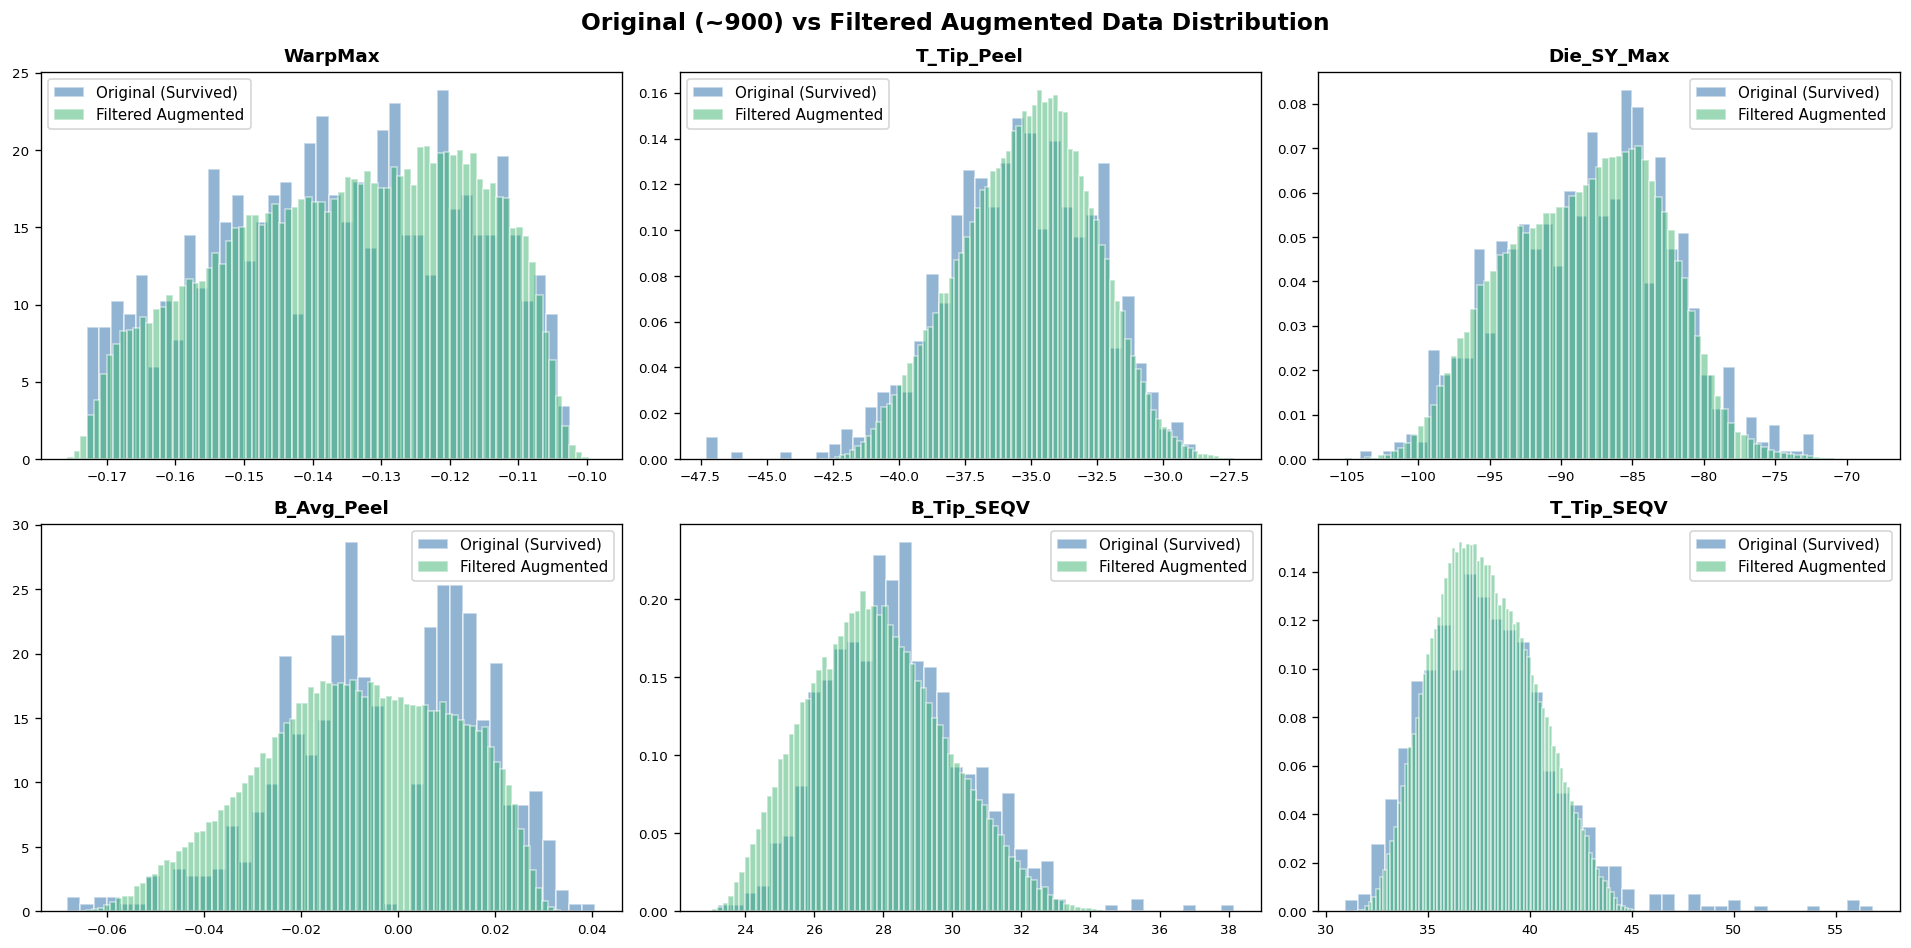

In [46]:
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====================================================================
# [6. 원본 데이터(df_peaks) 즉석 추출 로직 - 수정판]
# ====================================================================
valid_data = []     # 정상 추출된 데이터를 누적할 리스트
error_rows = []     # 읽기 오류가 발생한 Row_ID를 기록할 리스트

t_start = time.time()
print(f'\n{len(survived_ids)}개 생존 CSV에서 Max Peak 추출 시작 (시각화 비교용)...')

for i, row_id in enumerate(survived_ids):
    # 시계열 CSV 파일 경로 구성
    fpath = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    
    try:
        # 시계열 데이터 로드 
        df_ts = pd.read_csv(fpath)
        df_ts.columns = [c.strip() for c in df_ts.columns]
        
        # 결과 딕셔너리 초기화
        peak_dict = {'Row_ID': row_id}
        
        # 마스터 DOE에서 해당 Row의 P1~P6 가져오기 (인덱스 기반 매칭)
        # Row_ID 1 = 인덱스 0
        idx = row_id - 1 
        for p_col in ['P1','P2','P3','P4','P5','P6']:
            peak_dict[p_col] = df_master.loc[idx, p_col]
        
        # === 핵심 로직: 각 Y 채널별 '절댓값 최대 피크(부호 유지)' 추출 ===
        for y_col in Y_COLUMNS:
            if y_col in df_ts.columns:
                max_abs_idx = df_ts[y_col].abs().idxmax()
                peak_dict[y_col] = df_ts.loc[max_abs_idx, y_col]
            else:
                peak_dict[y_col] = np.nan
        
        valid_data.append(peak_dict)
        
    except Exception as e:
        error_rows.append((row_id, str(e)))

elapsed = time.time() - t_start

# 결과 취합
df_peaks = pd.DataFrame(valid_data)

print(f'\n=== Max Peak 추출 완료 ===')
print(f'성공: {len(df_peaks)}개 / 실패: {len(error_rows)}개 / 소요시간: {elapsed:.1f}초')

# 방어 코드: 추출 성공 데이터가 없을 경우 에러 방지
if df_peaks.empty:
    raise ValueError("추출된 데이터가 0개입니다. 경로 설정이나 마스터 파일 인덱스를 확인하세요.")

# NaN이 있는 행 확인 및 제거
nan_count = df_peaks[Y_COLUMNS].isnull().any(axis=1).sum()
if nan_count > 0:
    print(f'[경고] {nan_count}개 행에 NaN 존재 -> 해당 행 제거')
    df_peaks = df_peaks.dropna(subset=Y_COLUMNS).reset_index(drop=True)

# ====================================================================
# [7. 원본 vs Gatekeeper 필터링 완료 증강 데이터 분포 시각화]
# ====================================================================
# Step 2에서 방금 저장한 '분류 이후의 안전한 데이터셋' 로드
filtered_csv_path = 'Augmented_Class_Data.csv'
df_augmented_filtered = pd.read_csv(filtered_csv_path)

# 시각화할 6대 핵심 채널 (노이즈 배제)
check_cols = ['WarpMax', 'T_Tip_Peel', 'Die_SY_Max', 
              'B_Avg_Peel', 'B_Tip_SEQV', 'T_Tip_SEQV']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Original (~900) vs Filtered Augmented Data Distribution',
             fontsize=14, fontweight='bold')

for idx, y_col in enumerate(check_cols):
    ax = axes[idx // 3, idx % 3]
    
    # 원본 데이터 분포 (파란색 히스토그램)
    ax.hist(df_peaks[y_col], bins=40, density=True, alpha=0.6,
            color='steelblue', edgecolor='white', label='Original (Survived)')
    
    # Gatekeeper를 통과한 고품질 증강 데이터 분포 (녹색 히스토그램)
    ax.hist(df_augmented_filtered[y_col], bins=80, density=True, alpha=0.5,
            color='mediumseagreen', edgecolor='white', label='Filtered Augmented')
    
    ax.set_title(y_col, fontweight='bold', fontsize=11)
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


# [Step 3] 파레토 프론티어(Pareto Frontier) 타겟 곡선 추출

## 목표
역설계 AI(Step 4)에 입력할 **'물리적으로 도달 가능하면서도 이상적인 타겟 시계열 텐서'**를 생성한다.

## 파레토 비지배 정렬 (Non-dominated Sorting)
원본 생존 데이터(~900개)에서 **WarpMax**와 **T_Tip_Peel** 단 2개 변수의 절댓값을 기준으로
파레토 최적 DP(Frontier 0)를 선별한다.
```
판정 기준: 두 목적함수 모두 최소화
  - obj1 = |WarpMax|   → 패키지 휨 최소화
  - obj2 = |T_Tip_Peel| → 계면 박리 응력 최소화

비지배 조건:
  DP_j가 DP_i를 "지배"한다 = j가 모든 목적에서 i 이하이고, 최소 하나에서 엄격히 작다
  → 아무에게도 지배당하지 않는 DP만 파레토 Frontier 0으로 선정
```

## 핵심 채널 선정 (7채널)
GPR ARD 커널의 학습 결과(R² 기준)로 확정된 **신뢰 가능한 7개 채널**만 사용한다.
R²가 낮은 변수(T_Tip_Shear, T_Avg_Peel 등)는 예측 신뢰도가 부족하여 제외.
```
채널                GPR Test R²    역할
─────────────────────────────────────────────
WarpMax             0.999          최소화 메인 타겟 #1
T_Tip_Peel          0.773          최소화 메인 타겟 #2
Die_SY_Max          0.900          다이 모서리 응력 (Hard Constraint)
B_Avg_Peel          0.844          Bottom 평균 박리 (Hard Constraint)
B_Tip_SEQV          0.829          Bottom 끝단 등가응력 (Hard Constraint)
T_Tip_Strain        0.798          Top 끝단 변형률 (Hard Constraint)
T_Tip_SEQV          0.588          Top 끝단 등가응력 (경계선, 주의 필요)
```

## 유토피아 타겟 텐서 생성
```
파레토 Frontier 0 DP 선별
    ↓ 해당 Row_ID의 원본 시계열 CSV 호출 (617 timestep × 17열)
    ↓ 7대 핵심 채널만 추출
    ↓ 전 채널에 동일 스칼라(×0.9) 곱셈 → 진폭 10% 하향
    ↓ 물리적 위상차·파형 형태 100% 보존
Utopia_Target_Row_{Row_ID}.csv 저장 → Step 4로 전달
```

### ×0.9 스케일링의 물리적 의미
- 현재 파레토 1등의 곡선 형태(가열-유지-냉각 위상)는 그대로 유지
- 진폭만 10% 낮춰 **"현실에 가깝지만 약간 더 나은"** 유토피아 목표 설정
- 비현실적으로 낮은 목표(×0.5 등)는 AI가 물리적으로 불가능한 설계를 출력할 위험

## 출력
- `Utopia_Target_Tensors/Utopia_Target_Row_{ID}.csv`: 파레토 DP별 7채널 × 617 timestep
- 용도: Step 4 역설계 모델(1D-CNN)의 입력 텐서

In [49]:
# ====================================================================
# [1. 환경 및 타겟 설정]
# ====================================================================
CORE_7_CHANNELS = [
    'WarpMax', 'Die_SY_Max', 'B_Avg_Peel', 'B_Tip_SEQV', 
    'T_Tip_Strain', 'T_Tip_Peel', 'T_Tip_SEQV'
]

UTOPIA_RATIO = 0.90 
TENSOR_DIR = os.path.join(BASE_DIR, 'Utopia_Target_Tensors')  # 절대 경로 통일
os.makedirs(TENSOR_DIR, exist_ok=True)

print("=== [Step 3] 파레토 비지배 정렬 및 유토피아 타겟 추출 ===")

# ====================================================================
# [2. 다단계 Pareto Non-dominated Sorting (Frontier 0 + 1 + ...)]
# ====================================================================
obj1 = df_peaks['WarpMax'].abs().values
obj2 = df_peaks['T_Tip_Peel'].abs().values
scores = np.column_stack((obj1, obj2))

population_size = scores.shape[0]

# 다단계 비지배 정렬: Frontier 0, 1, 2, ... 순서로 계층 분류
# Frontier 0 = 최상위 (아무에게도 지배 안 당함)
# Frontier 1 = Frontier 0 제거 후 비지배 해
# ...반복
frontier_labels = np.full(population_size, -1, dtype=int)  # 각 DP의 Frontier 등급
remaining = np.ones(population_size, dtype=bool)             # 아직 분류 안 된 DP
frontier_level = 0

while remaining.any():
    remaining_idx = np.where(remaining)[0]
    current_scores = scores[remaining_idx]
    is_pareto = np.ones(len(remaining_idx), dtype=bool)
    
    for i in range(len(remaining_idx)):
        for j in range(len(remaining_idx)):
            if i == j:
                continue
            # j가 i를 지배하는지 판정
            if all(current_scores[j] <= current_scores[i]) and any(current_scores[j] < current_scores[i]):
                is_pareto[i] = False
                break
    
    # 현재 Frontier에 해당하는 DP에 등급 부여
    for k, idx in enumerate(remaining_idx):
        if is_pareto[k]:
            frontier_labels[idx] = frontier_level
            remaining[idx] = False
    
    print(f'  Frontier {frontier_level}: {is_pareto.sum()}개')
    frontier_level += 1
    
    # 안전 장치: 최대 10단계까지만
    if frontier_level >= 10:
        break

# Frontier 등급을 df_peaks에 추가
df_peaks['frontier'] = frontier_labels

# === 파레토 상위 N% 또는 최소 수량 확보 ===
MIN_PARETO_COUNT = 30  # 최소 확보 목표 (Step 4 학습에 필요한 하한)

# Frontier 0부터 순서대로 누적하여 최소 수량 충족될 때까지 확장
selected_frontiers = []
cumulative = 0
for level in range(frontier_level):
    count_at_level = (frontier_labels == level).sum()
    selected_frontiers.append(level)
    cumulative += count_at_level
    if cumulative >= MIN_PARETO_COUNT:
        break

df_pareto = df_peaks[df_peaks['frontier'].isin(selected_frontiers)].copy()
num_pareto = len(df_pareto)
max_frontier = max(selected_frontiers)

print(f'\n총 {population_size}개 중 파레토 Frontier 0~{max_frontier}: {num_pareto}개 ({num_pareto/population_size*100:.1f}%)')
print(f'  (Frontier 0만: {(frontier_labels==0).sum()}개 → 부족하여 Frontier {max_frontier}까지 확장)')

if num_pareto < MIN_PARETO_COUNT:
    print(f'[경고] {num_pareto}개로 목표({MIN_PARETO_COUNT})에 미달. 가용 데이터 전부 사용.')

=== [Step 3] 파레토 비지배 정렬 및 유토피아 타겟 추출 ===
  Frontier 0: 7개
  Frontier 1: 13개
  Frontier 2: 9개
  Frontier 3: 15개
  Frontier 4: 16개
  Frontier 5: 14개
  Frontier 6: 19개
  Frontier 7: 22개
  Frontier 8: 33개
  Frontier 9: 23개

총 667개 중 파레토 Frontier 0~3: 44개 (6.6%)
  (Frontier 0만: 7개 → 부족하여 Frontier 3까지 확장)


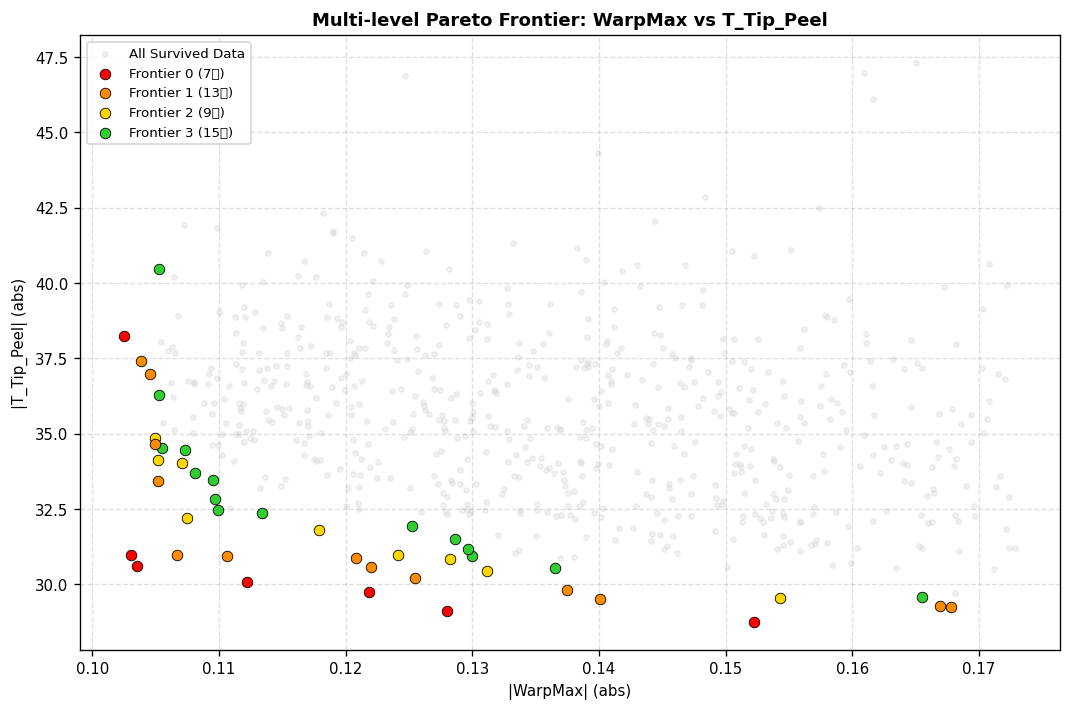

→ 빨간색(Frontier 0)에 가까울수록 WarpMax와 T_Tip_Peel이 동시에 작은 우수 설계
→ 총 44개의 유토피아 타겟 텐서가 Step 4로 전달됨


In [50]:
# ====================================================================
# [3. 다단계 파레토 프론티어 시각화]
# ====================================================================
plt.figure(figsize=(9, 6))

# 전체 데이터 (회색 배경)
plt.scatter(obj1, obj2, color='lightgray', alpha=0.3, s=10, label='All Survived Data')

# Frontier 등급별 색상 구분
colors = ['red', 'darkorange', 'gold', 'limegreen', 'deepskyblue']
for level in selected_frontiers:
    mask = frontier_labels == level
    n = mask.sum()
    c = colors[level] if level < len(colors) else 'gray'
    plt.scatter(obj1[mask], obj2[mask], color=c, s=40, edgecolors='black',
                linewidths=0.5, label=f'Frontier {level} ({n}개)', zorder=5-level)

plt.title('Multi-level Pareto Frontier: WarpMax vs T_Tip_Peel', fontweight='bold')
plt.xlabel('|WarpMax| (abs)')
plt.ylabel('|T_Tip_Peel| (abs)')
plt.legend(fontsize=8)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'→ 빨간색(Frontier 0)에 가까울수록 WarpMax와 T_Tip_Peel이 동시에 작은 우수 설계')
print(f'→ 총 {num_pareto}개의 유토피아 타겟 텐서가 Step 4로 전달됨')